## Importación de paquetes

In [314]:
import os
import numpy as np                  # Importación de la biblioteca numpy para el manejo de arreglos
import pandas as pd                 # Importación de la biblioteca pandas para el manejo de datos contenidos en una base de datos
import matplotlib.pyplot as plt     # Importación de la biblioteca para realizar la visualización de resultados mediante elementos gráficos
import seaborn as sns
np.set_printoptions(
    suppress=True,
    linewidth=100,
    precision=2
)
plt.rcParams['figure.dpi'] = 120

## Funciones Auxiliares

### Gráfico de Barra

In [315]:
def plot_grafico_barra(data_pandas, cols, titulo, xlabel, ylabel):
    # Configuración general
    sns.set_theme(
        style="ticks",
        context="notebook",
        font_scale=1.0
    )

    # Dimensiones fijas
    FIG_WIDTH = 7
    FIG_HEIGHT = 5

    # Selección correcta de columnas
    #cols = ['data', 'count']
    df =data_pandas.loc[:, cols]

    # Figura
    fig, ax = plt.subplots(
        figsize=(FIG_WIDTH, FIG_HEIGHT),
        dpi=120
    )

    # Gráfico correcto
    sns.barplot(
        data=df,
        x=cols[0],
        y=cols[1],
        palette='tab10',
        ax=ax,
        color='black'
    )

    # Título
    ax.set_title(
        titulo,
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    # Etiquetas
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Rotación de etiquetas
    ax.tick_params(axis='x', rotation=45)

    # Valores sobre barras
    for container in ax.containers:
        ax.bar_label(
            container,
            fontsize=10,
            padding=3
        )

    # Cuadrícula elegante
    ax.grid(axis='y', linestyle='-', alpha=0.8)

    # Bordes limpios
    sns.despine()

    plt.tight_layout()
    plt.show()

## Obtención de la ruta del script

In [316]:
os.getcwd()

'c:\\Users\\ernesto.molina\\Downloads'

## Importación de los datos

In [317]:
data_name = 'loan-data.csv'     # Nombre del archivo que contiene los datos a procesar

## Procesamiento del formato de los datos extraídos

### **Extracción de los datos proporcionados**

La carga de la información se realiza considerando todos los registros como cadenas de texto, con el propósito de evitar errores durante el proceso de lectura y almacenamiento de los datos. 

Se emplea el punto y coma (`;`) como delimitador para separar los distintos campos contenidos en el conjunto de datos.

In [318]:
raw_data_np = np.loadtxt(data_name, delimiter=';', dtype='str')     # Carga de los datos proporcionados en formato de cadena de caracteres para realizar, a posteriori, la clasificación de su formato
raw_data_np = raw_data_np.transpose()                               # Conversión de columnas a filas para un mejor procesamiento de los datos para su clasificación y casteo
etiquetas = raw_data_np[:,0]                                        # Extracción de las etiquetas
data = raw_data_np[:,1:]                                            # Extracción de los datos
print(etiquetas)
print(data[:,:5])

['id' 'issue_d' 'loan_amnt' 'loan_status' 'funded_amnt' 'term' 'int_rate' 'installment' 'grade'
 'sub_grade' 'verification_status' 'url' 'addr_state' 'total_pymnt']
[['48010226' '57693261' '59432726' '53222800' '57803010']
 ['May-15' '' 'Sep-15' 'Jul-15' 'Aug-15']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 ['Current' 'Current' 'Current' 'Current' 'Current']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 [' 36 months' ' 36 months' ' 36 months' ' 36 months' ' 36 months']
 ['13.33' 'þëè.89' 'íîå.53' 'þëè.89' '19.19']
 ['1184.86' '938.57' '494.86' '300.35' '296.78']
 ['C' 'A' 'B' 'A' '']
 ['C3' 'A5' 'B5' 'A5' 'E3']
 ['Verified' 'Source Verified' 'Verified' 'Not Verified' 'Source Verified']
 ['https://www.lendingclub.com/browse/loanDetail.action?loan_id=48010226'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=57693261'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=59432726'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=53222

Como resultado del proceso de carga y extracción de información se generan las siguientes estructuras de datos:

* *etiquetas*: arreglo que contiene los nombres de las variables o características presentes en el conjunto de datos original. Estas etiquetas permiten identificar cada atributo y facilitan la interpretación de la información almacenada.

* *data*: estructura que contiene los valores asociados a cada registro del conjunto de datos, manteniendo la correspondencia entre los datos almacenados y las etiquetas que los describen.

**Formato de los datos extraídos**

Una vez cargados los registros, se realiza un proceso de formateo de los datos con el objetivo de convertir cada elemento a un valor numérico de tipo punto flotante. 

Cuando un registro no puede convertirse debido a incompatibilidades en su formato o a la presencia de valores faltantes, se le asigna el valor especial `np.nan`, el cual permite identificar y gestionar posteriormente los datos no válidos o ausentes durante el análisis.

In [319]:
data_numero = []
for i in data:
    temporal = []
    for j in i:
        try:
            x = float(j)
        except:
            x = np.nan
        finally:
            temporal.append(x)
    data_numero.append(temporal)
data_numero = np.array(data_numero)
print(data_numero[:,:5])

[[48010226.   57693261.   59432726.   53222800.   57803010.  ]
 [        nan         nan         nan         nan         nan]
 [   35000.      30000.      15000.       9600.       8075.  ]
 [        nan         nan         nan         nan         nan]
 [   35000.      30000.      15000.       9600.       8075.  ]
 [        nan         nan         nan         nan         nan]
 [      13.33         nan         nan         nan       19.19]
 [    1184.86      938.57      494.86      300.35      296.78]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [    9452.96     4679.7      1969.83     1793.68     1178.51]]


Como resultado de este proceso se obtienen la siguiente variable:

- **data_numero**: conjunto de datos cuyos elementos han sido convertidos a valores numéricos de tipo punto flotante. Aquellos registros que no pudieron ser transformados debido a incompatibilidades en su formato se representan mediante el valor especial `np.nan`.

**Contabilización de datos nulos**

Se realiza un análisis de los valores nulos presentes en cada una de las categorías que conforman el conjunto de datos proporcionado. Para cada categoría, se determina el porcentaje que estos representan respecto al número total de datos disponibles.

A partir de este análisis se consideran los siguientes criterios:

- Si el porcentaje de valores nulos es igual al **100 %**, se asume que la categoría no contiene información numérica válida y, por tanto, corresponde a una variable de carácter categórico o no numérico.
- Si el porcentaje de valores nulos es inferior al **100 %**, se considera que la categoría contiene al menos algunos datos numéricos válidos.
- Si el porcentaje de valores nulos es mayor que **0 %**, la categoría presenta datos faltantes, por lo que podría requerirse posteriormente la aplicación de técnicas de imputación para completar la información y garantizar la calidad del análisis.

In [320]:
cantidad_nulos = []
for i in data_numero:
    cantidad_nulos.append(int(pd.isna(i).sum()/len(i)*100))
index_categoricos, index_numericos = [], []
for i in range(len(cantidad_nulos)):
    if cantidad_nulos[i] == 100:
        index_categoricos.append(i)
    else:
        index_numericos.append(i)
print(index_categoricos)
print(index_numericos)

[1, 3, 5, 8, 9, 10, 11, 12]
[0, 2, 4, 6, 7, 13]


Como resultado de este proceso se obtienen las siguientes variables:

- **index_categoricos**: conjunto de índices asociados a las categorías cuyos registros corresponden principalmente a datos de carácter categórico o no numérico.

- **index_numericos**: conjunto de índices asociados a las categorías que contienen datos de naturaleza numérica y que, por tanto, pueden ser utilizadas en análisis estadísticos y procedimientos de modelado cuantitativo.

### **Agrupamiento de datos categóricos**

In [321]:
etiqueta_categoricos, data_categoricos = [], []
for i in index_categoricos:
    etiqueta_categoricos.append(etiquetas[i])
    data_categoricos.append(raw_data_np[i][1:])
data_categoricos = np.array(data_categoricos)
print(data_categoricos[:,:5])
print(etiqueta_categoricos)

[['May-15' '' 'Sep-15' 'Jul-15' 'Aug-15']
 ['Current' 'Current' 'Current' 'Current' 'Current']
 [' 36 months' ' 36 months' ' 36 months' ' 36 months' ' 36 months']
 ['C' 'A' 'B' 'A' '']
 ['C3' 'A5' 'B5' 'A5' 'E3']
 ['Verified' 'Source Verified' 'Verified' 'Not Verified' 'Source Verified']
 ['https://www.lendingclub.com/browse/loanDetail.action?loan_id=48010226'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=57693261'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=59432726'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=53222800'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=57803010']
 ['CA' 'NY' 'PA' 'OH' 'TX']]
[np.str_('issue_d'), np.str_('loan_status'), np.str_('term'), np.str_('grade'), np.str_('sub_grade'), np.str_('verification_status'), np.str_('url'), np.str_('addr_state')]


### **Agrupamiento de datos numéricos**

In [322]:
etiqueta_numericos, data_numericos = [], []
for i in index_numericos:
    etiqueta_numericos.append(etiquetas[i])
    data_numericos.append(raw_data_np[i][1:])
data_numericos = np.array(data_numericos)
print(data_numericos[:,:5])
print(etiqueta_numericos)

[['48010226' '57693261' '59432726' '53222800' '57803010']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 ['13.33' 'þëè.89' 'íîå.53' 'þëè.89' '19.19']
 ['1184.86' '938.57' '494.86' '300.35' '296.78']
 ['9452.96' '4679.7' '1969.83' '1793.68' '1178.51']]
[np.str_('id'), np.str_('loan_amnt'), np.str_('funded_amnt'), np.str_('int_rate'), np.str_('installment'), np.str_('total_pymnt')]


## Procesamiento de datos categóricos

### **Cantidad de datos categóricos**

In [597]:
print(len(etiqueta_categoricos))
print(etiqueta_categoricos)
data_categoricos_codificados, etiquetas_categoricos_codificados = [], []        # Inicialización de arreglos vacíos para almacenar los datos y las etiquetas asociados a variables categóricas y binarias procesadas.
print(data_categoricos[:,:5])
valor = -1

8
[np.str_('issue_d'), np.str_('loan_status'), np.str_('term'), np.str_('grade'), np.str_('sub_grade'), np.str_('verification_status'), np.str_('url'), np.str_('addr_state')]
[['May-15' '' 'Sep-15' 'Jul-15' 'Aug-15']
 ['Current' 'Current' 'Current' 'Current' 'Current']
 [' 36 months' ' 36 months' ' 36 months' ' 36 months' ' 36 months']
 ['C' 'A' 'B' 'A' '']
 ['C3' 'A5' 'B5' 'A5' 'E3']
 ['Verified' 'Source Verified' 'Verified' 'Not Verified' 'Source Verified']
 ['https://www.lendingclub.com/browse/loanDetail.action?loan_id=48010226'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=57693261'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=59432726'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=53222800'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=57803010']
 ['CA' 'NY' 'PA' 'OH' 'TX']]


### **Categoría: issue_d**

#### *Exploración general de los datos*

In [598]:
valor += 1
print(np.unique(data_categoricos[valor]))       # Categorías contenidas en la primera columna correspondiente a los datos categóricos ('issue_d')
print(etiqueta_categoricos[valor])

['' 'Apr-15' 'Aug-15' 'Dec-15' 'Feb-15' 'Jan-15' 'Jul-15' 'Jun-15' 'Mar-15' 'May-15' 'Nov-15'
 'Oct-15' 'Sep-15']
issue_d


*Se observa consistencia en las etiquetas contenidas en la categoría, puesto que ninguna de las observaciones del conjunto corresponde a valores equivalentes con distintas codificaciones. Por lo tanto, no es necesario aplicar un procedimiento de estandarización o corrección de etiquetas.*

#### *Cantidad de valores únicos*

In [599]:
print(len(np.unique(data_categoricos[valor])))  # Cantidad de categorías únicas contenidas en la columna 'issue_d'

13


*El análisis de esta variable revela la existencia de* **13** *categorías diferentes*.

- *De estas categorías*, **12** *se corresponden a los meses del año 2015, indicando el período temporal asociado a cada registro.* 

- *Por otra parte, la categoría restante agrupa aquellos registros para los cuales no se dispone de información, encontrándose representada mediante una etiqueta vacía. La presencia de esta última categoría evidencia la existencia de valores faltantes dentro de la variable analizada.*

#### *Proceso de Codificación de Categorías*

*Inicialización de la lista que contiene los meses en orden cronológico. Esta lista es utilizada para realizar la codificación de la información contenida en la columna analizada en esta sección.*

In [600]:
meses_ordenados = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
dict_meses = {}
for i in range(len(meses_ordenados)):
    dict_meses[meses_ordenados[i]] = i
dict_meses

{'': 0,
 'Jan': 1,
 'Feb': 2,
 'Mar': 3,
 'Apr': 4,
 'May': 5,
 'Jun': 6,
 'Jul': 7,
 'Aug': 8,
 'Sep': 9,
 'Oct': 10,
 'Nov': 11,
 'Dec': 12}

*Codificación de los datos contenidos en la columna, y renombramiento de la columna para una mejor interpretación.*

In [601]:
data_categoricos_codificados.append([dict_meses[data_categoricos[valor][i].split('-')[0]] for i in range(len(data_categoricos[valor]))])
etiquetas_categoricos_codificados.append('fecha_prestamo')

In [602]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(15)

,fecha_prestamo
0,5
1,0
2,9
3,7
4,8
5,10
6,9
7,4
8,11
9,11


*La transformación de esta variable categórica se lleva a cabo mediante la asignación de valores numéricos a cada mes de registro, respetando su orden cronológico. Este procedimiento permite incorporar la naturaleza temporal de la variable en los análisis realizados.*

*Adicionalmente, se renombró la columna para proporcionar una descripción más representativa de su contenido y facilitar la interpretación de los resultados obtenidos.*

#### *Estructura de los Datos Modificados*

In [603]:
pandas_date = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_date['porcentaje'] = pandas_date['count']/len(data_categoricos_codificados[-1])*100
pandas_date

,data,count,porcentaje
0,10,1095,10.95
1,7,1061,10.61
2,12,997,9.97
3,11,847,8.47
4,8,846,8.46
5,1,770,7.70
6,4,757,7.57
7,5,741,7.41
8,6,654,6.54
9,9,643,6.43


#### *Graficado de los Datos Proveidos*

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_2896\3688550933.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


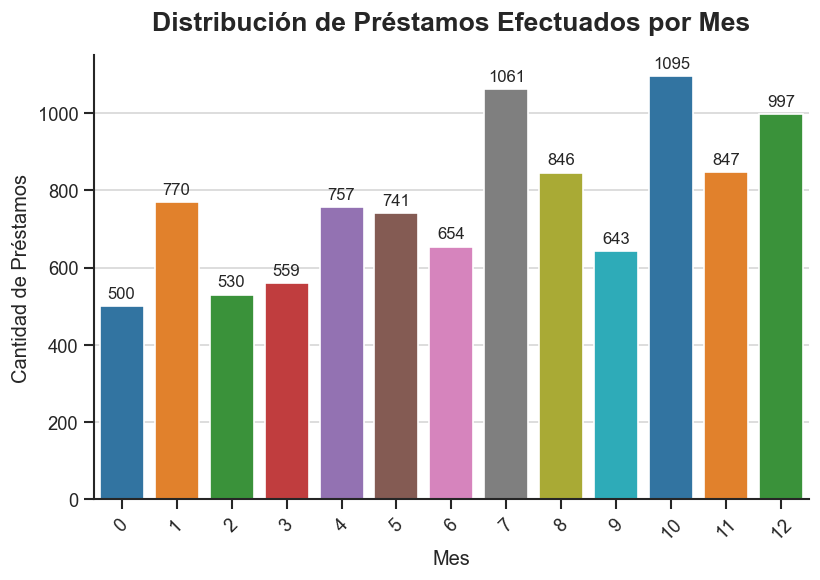

In [604]:
plot_grafico_barra(
    titulo='Distribución de Préstamos Efectuados por Mes',
    data_pandas=pandas_date,
    cols=['data', 'count'],
    xlabel='Mes',
    ylabel='Cantidad de Préstamos'
)

*En la gráfica se observa que durante el segundo semestre del período analizado se presentó un incremento en la cantidad de préstamos solicitados a las instituciones consideradas en el estudio, lo que sugiere una tendencia de crecimiento en la demanda de crédito en dicha etapa.*

#### 🧠 *Análisis Preliminar de la Distribución de Fechas de Depósito*

##### 📌 1. **Patrón principal (meses del año)**

Los valores están relativamente bien distribuidos entre los meses:

- El mes con mayor frecuencia es 10 -> Octubre (1095 casos)
- Le siguen 7 -> Julio (1061) y 12 -> Diciembre (997)
- El resto de meses se encuentran en un rango entre ~530 y ~850

👉 Esto sugiere que:

- No hay una fuerte estacionalidad extrema en la recolección de datos
- Aunque sí hay ligeras concentraciones en meses específicos (octubre, julio, diciembre)

##### ⚠️ 2. **Valor “0” (No especificado)**
- Frecuencia: 500 casos
- Representa un volumen importante (~equivalente a un mes completo)

👉 Esto es relevante porque:

- No es un valor marginal
- Puede afectar análisis temporales si no se trata adecuadamente
- Introduce incertidumbre en el componente temporal del dataset

##### 📈 3. **Interpretación global**

En conjunto, la variable muestra:

- Distribución relativamente homogénea entre meses
- Leve concentración en ciertos meses (posible efecto operativo o de negocio)
- Presencia significativa de valores faltantes codificados como 0

##### ⚠️ 4. **Implicación analítica**

Si esta variable se usa en análisis temporal:

- ❌ No conviene tratarla como continua sin cuidado
- ❌ El “0” no debe interpretarse como mes real
- ✅ Debe tratarse como categoría especial o missing value

Opciones recomendadas:

- Separarlo como NaN o categoría “No especificado”
- Excluirlo en análisis de estacionalidad
- Mantenerlo solo para análisis de calidad de datos

##### ✍️ **Conclusión breve** (lista para informe)

La variable presenta una distribución relativamente uniforme entre los meses del año, con ligeras concentraciones en los meses 7, 10 y 12. Sin embargo, se observa la presencia de un valor codificado como 0, el cual corresponde a información no especificada y representa una proporción no despreciable del conjunto de datos, lo cual debe ser considerado en el análisis temporal para evitar interpretaciones sesgadas.

### **Categoría: loan_status**

#### *Exploración general de los datos*

In [605]:
valor += 1
print(np.unique(data_categoricos[valor]))       # Categorías contenidas en la primera columna correspondiente a los datos categóricos ('loan_status')
print(etiqueta_categoricos[valor])

['' 'Charged Off' 'Current' 'Default' 'Fully Paid' 'In Grace Period' 'Issued' 'Late (16-30 days)'
 'Late (31-120 days)']
loan_status


*Se observa consistencia en las etiquetas contenidas en la categoría, puesto que ninguna de las observaciones del conjunto corresponde a valores equivalentes con distintas codificaciones. Por lo tanto, no es necesario aplicar un procedimiento de estandarización o corrección de etiquetas.*

#### *Cantidad de valores únicos*

In [606]:
print(np.unique(data_categoricos[valor]))

['' 'Charged Off' 'Current' 'Default' 'Fully Paid' 'In Grace Period' 'Issued' 'Late (16-30 days)'
 'Late (31-120 days)']


*Las categorías integradas en esta columna son las siguientes:*
* **'Charged Off'**: *El préstamo ha sido clasificado como incobrable por la entidad financiera. Estado negativo para la institución financiera.*
* **'Current'**: *El préstamo se encuentra activo y los pagos se realizan conforme a lo establecido. Estado positivo para la institución financiera.*
* **'Default'**: *El préstamo ha entrado en incumplimiento de pago. Estado negativo para la institución financiera.*
* **'Fully Paid'**: *El préstamo fue liquidado en su totalidad. Estado positivo para la institución financiera.*
* **'In Grace Period'**: *El préstamo se encuentra dentro del período de gracia permitido para regularizar pagos atrasados.  Estado positivo para la instintución financiera.*
* **'Issued'**: *El préstamo ha sido aprobado y emitido recientemente. Se considera favorable debido a que no existe evidencia de incumplimiento al momento de la emisión del préstamo. Estado positivo para la institución financiera.*
* **'Late (16-30 days)'**: *El préstamo presenta un retraso en los pagos de entre 16 y 30 días. Aunque este estado refleja un retraso en el cumplimiento de las obligaciones de pago, se clasifica dentro de la categoría favorable debido a que el préstamo aún no ha alcanzado un nivel de morosidad severa y existe una probabilidad razonable de regularización por parte del cliente. Estado positivo para la institución financiera.*
* **'Late (31-120 days)'**: *El préstamo presenta un retraso en los pagos de entre 31 y 120 días. Este estado se considera como no favorable, puesto que existe una alto riesgo de que el cliente no realice los pagos de su deuda. Estado negativo para la institución financiera.*
* '': *Clasificación vacía. Debido a la ausencia de información que permita determinar el estado real del préstamo, estos registros se clasifican como no favorables bajo un criterio conservador de evaluación del riesgo. Estado negativo para la institución financiera.*

#### *Proceso de Rectificación de la Codificación de Categorías*

*Los datos categóricos originales se mantienen, asignando la etiqueta no definida como “No especificado”, ya que esta información puede resultar útil en análisis posteriores que requieran una segmentación más detallada de los distintos estados registrados.*

In [607]:
data_categoricos_codificados.append([i if i != '' else np.str_('No especificado') for i in data_categoricos[valor]])    # Recategorización del estado no especificado en los datos crudos proporcionados
etiquetas_categoricos_codificados.append('estado_prestamo')                                                             # Renombramiento de la categoría para una mejor interpretación

#### *Estructura de los Datos Modificados*

In [608]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(15)

,fecha_prestamo,estado_prestamo
0,5,Current
1,0,Current
2,9,Current
3,7,Current
4,8,Current
5,10,Current
6,9,Current
7,4,Current
8,11,Current
9,11,Current


In [609]:
pandas_estado = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_estado['porcentaje'] = pandas_estado['count']/len(data_categoricos_codificados[-1])*100
pandas_estado

,data,count,porcentaje
0,Current,8538,85.38
1,Fully Paid,505,5.05
2,No especificado,500,5.00
3,Issued,184,1.84
4,Late (31-120 days),115,1.15
5,Charged Off,61,0.61
6,In Grace Period,56,0.56
7,Late (16-30 days),30,0.30
8,Default,11,0.11


*La distribución resulta altamente informativa, ya que permite observar de forma directa la estructura de riesgo de la cartera, así como posibles inconsistencias o problemas de calidad en los datos.*

#### *Graficado de la Distribución de los Estados de los Préstamos*

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_2896\3688550933.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


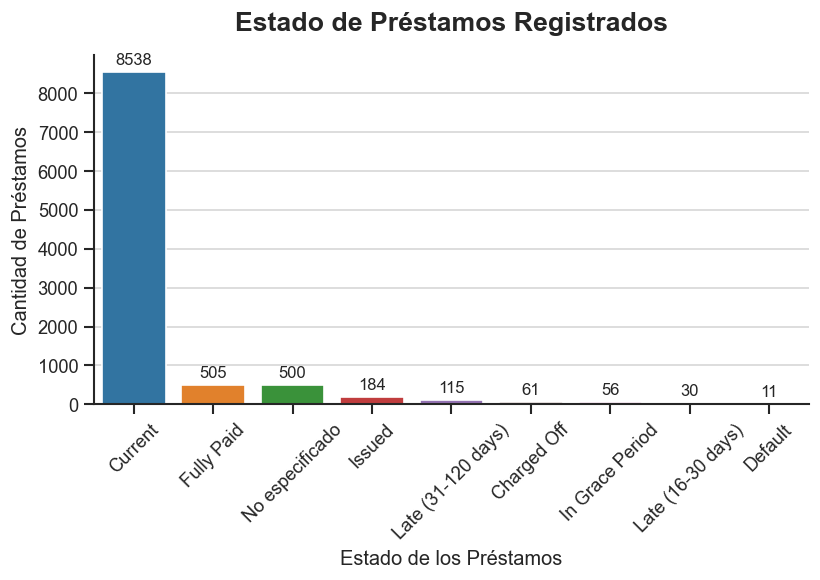

In [610]:
plot_grafico_barra(
    titulo='Estado de Préstamos Registrados',
    data_pandas=pandas_estado,
    cols=['data', 'count'],
    xlabel='Estado de los Préstamos',
    ylabel='Cantidad de Préstamos'
)

*Se observa una alta asimetría en la distribución de los préstamos según su estado, con una clara predominancia de aquellos clasificados como “al corriente”, los cuales superan ampliamente en frecuencia al resto de categorías definidas. Asimismo, destaca la presencia significativa de registros en la categoría “No especificado”, cuya magnitud resulta superior a la mayoría de los estados restantes, a excepción de los préstamos “Current” y “Fully Paid”. Esta situación sugiere la existencia de una posible pérdida de información o limitaciones en la clasificación de los datos, lo cual podría influir en la interpretación global de la cartera.*

#### 🧠 *Análisis Preliminar de la Distribución de Categorías de Estados de Cuenta*

##### Análisis de los Estados *Saludables* (*Current, Fully Paid, Issued*)

In [611]:
print((8538 + 505 + 184)/len(data_categoricos_codificados[-1])*100)

92.27


*Estados **buenos** o saludables* - 92.27 %

🟢 Current (8538) → domina ampliamente la distribución

✅ Fully Paid (505) → préstamos cerrados de forma exitosa

🆕 Issued (184) → préstamos recientemente emitidos, sin historial de comportamiento aún

En conjunto, la cartera se encuentra fuertemente concentrada en préstamos activos y, en su mayoría, con un comportamiento saludable. 

Los estados considerados “buenos” representan aproximadamente el 92.27 % del total de préstamos otorgados, en términos absolutos.

##### Análisis de los Estados *Intermedios* (*In Grace Period, Late (16-30 days)*)

In [612]:
print((56 + 30)/len(data_categoricos_codificados[-1])*100)

0.86


*Estados intermedios (zona de alerta)* - 0.86 %

🟡 In Grace Period (56) → préstamos dentro del período de gracia, con posibilidad de regularización sin consecuencias mayores.

⚠️ Late (16–30 days) (30) → préstamos con retrasos iniciales en los pagos, considerados una señal temprana de posible deterioro crediticio.

Estos estados representan una zona de riesgo moderado, ya que reflejan clientes que han comenzado a presentar dificultades de pago, pero que aún cuentan con una alta probabilidad de recuperación mediante acciones de seguimiento oportunas.

📊 En conjunto, los estados financieros intermedios representan aproximadamente el 0.86 % del total de préstamos otorgados, por lo que su incidencia dentro de la cartera es relativamente baja en términos absolutos.

##### Análisis de los Estados de *Alto Riesgo* (*Default, Charged Off, Late (31-120 days)*)

In [613]:
print((115 + 11 + 61)/len(data_categoricos_codificados[-1])*100)

1.87


*Estados de alto riesgo o pérdida* - 1.87 %

🔴 Late (31–120 days) (115) → préstamos con retrasos significativos en los pagos, lo que indica una alta probabilidad de incumplimiento.

⛔ Default (11) → préstamos en situación de incumplimiento, donde el prestatario ha dejado de cumplir con sus obligaciones de pago.

💸 Charged Off (61) → préstamos considerados como pérdidas por la institución financiera, tras agotar las acciones de recuperación correspondientes.

Estos estados reflejan un deterioro significativo de la calidad crediticia de la cartera, ya que corresponden a préstamos con un elevado riesgo de impago o que han sido clasificados directamente como pérdidas.

📉 En conjunto, los estados financieros de alto riesgo o pérdida representan aproximadamente el 1.87 % del total de préstamos otorgados, por lo que, aunque su proporción es reducida, constituyen el segmento de mayor interés para los análisis de riesgo crediticio y la construcción de modelos predictivos de incumplimiento.

##### Análisis de los Estados *No Especificados*

In [614]:
print((500)/len(data_categoricos_codificados[-1])*100)

5.0


*Categoría "No especificado" (500 casos)* - 5 %

Esta categoría constituye un punto de especial interés dentro del análisis, ya que representa la tercera categoría con mayor frecuencia en el conjunto de datos. 

Su volumen es comparable al de estados relevantes como Fully Paid, por lo que no puede considerarse un conjunto residual o insignificante.

⚠️ Es la tercera categoría más numerosa del conjunto de datos.

📊 Su frecuencia es cercana a la observada en préstamos Fully Paid.

🔍 Puede introducir sesgos en los análisis estadísticos y en la construcción de modelos predictivos si no se trata adecuadamente.

🧹 Sugiere la existencia de información faltante o inconsistencias en el proceso de recopilación y almacenamiento de los datos.

La presencia de esta categoría puede estar asociada a diferentes factores:

💡 Debido a su tamaño relativo, se recomienda conservar esta categoría durante las etapas iniciales del análisis exploratorio y evaluar posteriormente su comportamiento respecto a las demás variables. Esto permitirá determinar si corresponde a un patrón específico de clientes o préstamos, o si se trata únicamente de registros con información incompleta.

##### Conclusiones del Análisis Preliminar

Se puede considerar la creación de una segunda variable categórica que agrupe los estados de los préstamos según su nivel de riesgo. Esta clasificación permitiría desarrollar segmentaciones más específicas en análisis posteriores, facilitando la evaluación del estado financiero de la institución y la identificación de distintos niveles de exposición al riesgo crediticio.

Esta nueva categorización puede corresponderse con la siguiente:

- **'No Especificado'**

- **'Bajo'**

- **'Intermedio'**

- **'Alto'**

In [615]:
dict_riesgo = {
    'Bajo' : ['Current', 'Fully Paid', 'Issued'],
    'Intermedio' : ['In Grace Period', 'Late (16-30 days)'],
    'Alto' : ['Default', 'Charged Off', 'Late (31-120 days)']
}

In [616]:
keys_dict = dict_riesgo.keys()
temporal_categoria = []
for i in data_categoricos_codificados[-1]:
    if i != 'No especificado':
        for k in keys_dict:
            if i in dict_riesgo[k]:
                temporal_categoria.append(k)
                break
    else:
        temporal_categoria.append(str(i))

In [617]:
data_categoricos_codificados.append(temporal_categoria)
etiquetas_categoricos_codificados.append('riesgo_prestamo')    

In [618]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(15)

,fecha_prestamo,estado_prestamo,riesgo_prestamo
0,5,Current,Bajo
1,0,Current,Bajo
2,9,Current,Bajo
3,7,Current,Bajo
4,8,Current,Bajo
5,10,Current,Bajo
6,9,Current,Bajo
7,4,Current,Bajo
8,11,Current,Bajo
9,11,Current,Bajo


A partir de la distribución observada, es posible identificar los siguientes patrones:

- La distribución asociada a los diferentes estados del préstamo presenta un marcado desbalance entre categorías (Fuerte desbalance de clases (muy relevante metodológicamente)).

- Existe un claro predominio de los préstamos clasificados en estado Current, lo que indica que la mayor parte de los créditos se encuentran activos y al corriente en sus obligaciones de pago (Una cartera mayoritariamente sana o activa).

- Los estados asociados a riesgos intermedios y altos niveles de morosidad presentan una frecuencia de ocurrencia considerablemente menor, por lo que constituyen eventos poco frecuentes dentro del conjunto de datos (Baja proporción de riesgo).

- Se identifica una categoría correspondiente a registros con información no especificada (No especificado), cuya frecuencia es superior a la observada en varias de las categorías asociadas a riesgo crediticio. Debido a su magnitud, esta categoría puede introducir sesgos relevantes en análisis posteriores, particularmente en aquellos relacionados con la caracterización del riesgo y la construcción de modelos predictivos (Presencia no despreciable de datos incompletos).

In [619]:
pandas_riesgo = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_riesgo['porcentaje'] = pandas_riesgo['count']/len(data_categoricos_codificados[-1])*100
pandas_riesgo

,data,count,porcentaje
0,Bajo,9227,92.27
1,No especificado,500,5.00
2,Alto,187,1.87
3,Intermedio,86,0.86


C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_2896\3688550933.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


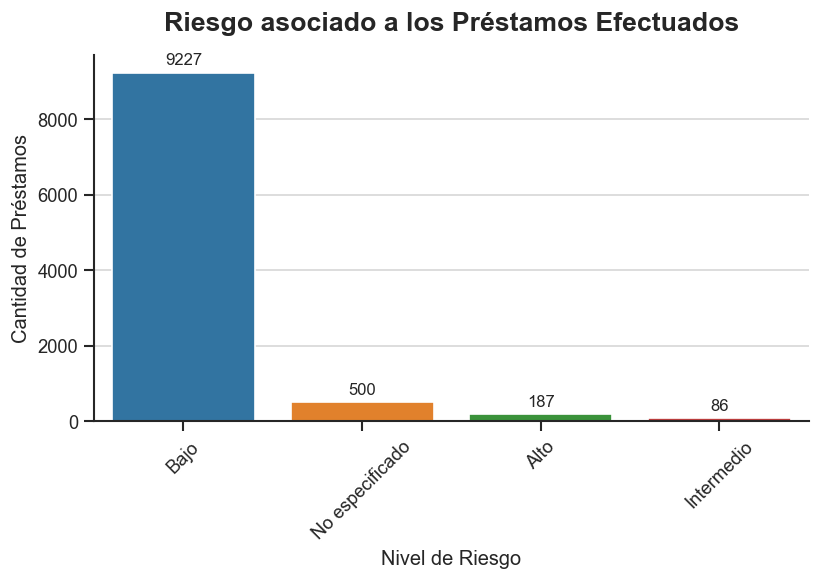

In [620]:
plot_grafico_barra(
    titulo='Riesgo asociado a los Préstamos Efectuados',
    data_pandas=pandas_riesgo,
    cols=['data', 'count'],
    xlabel='Nivel de Riesgo',
    ylabel='Cantidad de Préstamos'
)

*Se observa que el nivel de riesgo asociado a la cartera de la institución financiera es relativamente bajo en términos de la proporción de préstamos clasificados dentro de las categorías de riesgo. No obstante, la categoría “No especificado” presenta una magnitud superior a la de los préstamos de riesgo medio y alto, lo cual constituye un punto crítico en el análisis. Esta situación sugiere la posible introducción de sesgos en la interpretación de la distribución de riesgo, en caso de no realizarse una adecuada segmentación o tratamiento de los registros que no han sido correctamente identificados.*

#### *Proceso de Conversión de la Categoría a Binario*  (Imputación de Valores Ausentes)

*Para facilitar el análisis del estado financiero de la institución, se realiza una transformación de los datos categóricos asociados al estado del préstamo en una representación binaria, donde cada registro se clasifica de acuerdo con su condición positiva o negativa para la entidad financiera.*

In [621]:
print(np.unique(data_categoricos_codificados[-2]))
condicion_positiva = ['Current', 'Fully Paid', 'In Grace Period', 'Issued', 'Late (16-30 days)']

['Charged Off' 'Current' 'Default' 'Fully Paid' 'In Grace Period' 'Issued' 'Late (16-30 days)'
 'Late (31-120 days)' 'No especificado']


In [622]:
data_categoricos_codificados.append([1 if i in condicion_positiva else 0 for i in data_categoricos[valor]])    # Recategorización del estado no especificado en los datos crudos proporcionados
etiquetas_categoricos_codificados.append('clasificacion_estado_prestamo')   

In [623]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(15)

,fecha_prestamo,estado_prestamo,riesgo_prestamo,clasificacion_estado_prestamo
0,5,Current,Bajo,1
1,0,Current,Bajo,1
2,9,Current,Bajo,1
3,7,Current,Bajo,1
4,8,Current,Bajo,1
5,10,Current,Bajo,1
6,9,Current,Bajo,1
7,4,Current,Bajo,1
8,11,Current,Bajo,1
9,11,Current,Bajo,1


*La recategorización de esta variable a una variable binaria se llevó a cabo de manera adecuada, la cual clasifica el estado del préstamo como positivo (1) o negativo (0) para la institución financiera.*

In [624]:
pandas_estado_prestamo = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_estado_prestamo['porcentaje'] = pandas_estado_prestamo['count']/len(data_categoricos_codificados[-1])*100
pandas_estado_prestamo

,data,count,porcentaje
0,1,9313,93.13
1,0,687,6.87


C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_2896\3688550933.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


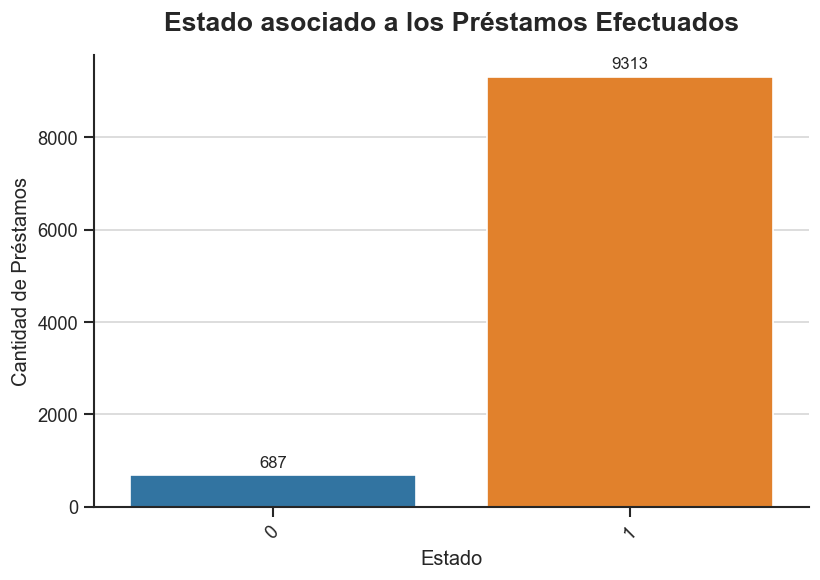

In [625]:
plot_grafico_barra(
    titulo='Estado asociado a los Préstamos Efectuados',
    data_pandas=pandas_estado_prestamo,
    cols=['data', 'count'],
    xlabel='Estado',
    ylabel='Cantidad de Préstamos'
)

*La mayoría de los préstamos efectuados presentan un estado favorable, lo cual, en términos relativos al total de operaciones registradas, sugiere una gestión generalmente adecuada por parte de las instituciones financieras. Este resultado debe interpretarse con cautela, ya que se ha adoptado una perspectiva conservadora al considerar los préstamos no categorizados dentro del balance negativo de la institución. Esta decisión puede influir en la evaluación global del desempeño crediticio y en la estimación del nivel real de riesgo asociado a la cartera.*

### **Categoría: term**

#### *Exploración general de los datos*

In [626]:
valor += 1
print(np.unique(data_categoricos[valor]))       # Categorías contenidas en la primera columna correspondiente a los datos categóricos ('issue_d')
print(etiqueta_categoricos[valor])

['' ' 36 months' ' 60 months']
term


*Se observa consistencia en las etiquetas contenidas en la categoría, puesto que ninguna de las observaciones del conjunto corresponde a valores equivalentes con distintas codificaciones. Por lo tanto, no es necesario aplicar un procedimiento de estandarización o corrección de etiquetas.*

#### *Cantidad de valores únicos*

In [627]:
print(len(np.unique(data_categoricos[valor])))  # Cantidad de categorías únicas contenidas en la columna 'issue_d'

3


Las categorías presentes en esta columna son las siguientes:

* '36 months': préstamo con una duración establecida de 36 meses.
* '60 months': préstamo con una duración establecida de 60 meses.
* '': valor vacío que representa la ausencia de información sobre el plazo de duración del préstamo.

Se debe realizar una mejor en el formato de la categoría establecida en esta columnas, de manera que la cadena de caracteres no posea espacios injustificados a su derecha e izquierda. Posteriormente, se puede extraer el número de meses en los cuales se acordó el préstamo, para simplificar la información a la mínima requerida. La etiqueta vacía, con tal de no perder la información, se recomienda modificar con una etiqueta de no especificado.

Para cuestión relacionada al desarrollo de estudios del estado financiero de la institución, se recomienda modificar los valores no especificado al máximo valor registrado en los datos proporcionados (60 meses), para que dicha información sea incluida en el análisis.

#### *Proceso de Corrección de los Valores incluidos en la Categoría*

In [636]:
list_char = np.char.split(np.char.strip(data_categoricos[valor]), ' ')
temporal = [int(i[0]) if len(i)>0 and i[0] != '' else 'No especificado' for i in list_char]
data_categoricos_codificados.append(temporal)
etiquetas_categoricos_codificados.append('duracion_prestamo_meses')

#### *Estructura de los Datos Modificados*

In [637]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(15)

,fecha_prestamo,estado_prestamo,riesgo_prestamo,clasificacion_estado_prestamo,duracion_prestamo_meses,duracion_prestamo_meses_imputados,duracion_prestamo_meses
0,5,Current,Bajo,1,36,36,36
1,0,Current,Bajo,1,36,36,36
2,9,Current,Bajo,1,36,36,36
3,7,Current,Bajo,1,36,36,36
4,8,Current,Bajo,1,36,36,36
5,10,Current,Bajo,1,60,60,60
6,9,Current,Bajo,1,60,60,60
7,4,Current,Bajo,1,36,36,36
8,11,Current,Bajo,1,36,36,36
9,11,Current,Bajo,1,36,36,36


#### *Graficado de la Distribución de los Estados de los Préstamos*

In [638]:
pandas_termino = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_termino['porcentaje'] = pandas_termino['count']/len(data_categoricos_codificados[-1])*100
pandas_termino

,data,count,porcentaje
0,36,6281,62.81
1,60,3219,32.19
2,No especificado,500,5.00


C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_2896\3688550933.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


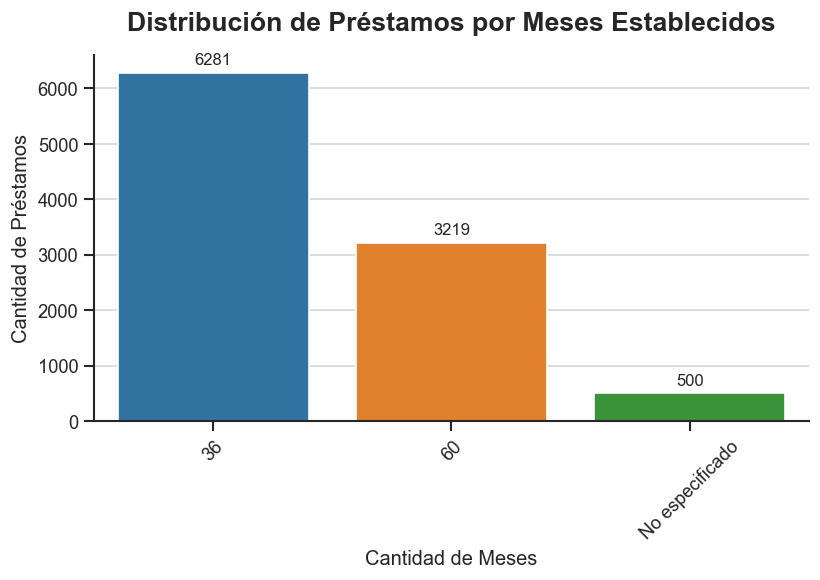

In [639]:
plot_grafico_barra(
    titulo='Distribución de Préstamos por Meses Establecidos',
    data_pandas=pandas_termino,
    cols=['data', 'count'],
    xlabel='Cantidad de Meses',
    ylabel='Cantidad de Préstamos'
)

*Se observa un predominio de préstamos con plazo de amortización de 36 meses, seguido de aquellos con una duración de 60 meses. Asimismo, se identifica la presencia de registros con información faltante respecto al plazo del préstamo.*

*Dado que esta última categoría representa una proporción reducida dentro del conjunto de datos, su influencia en la distribución global es limitada. Por ello, el tratamiento de estos valores puede abordarse mediante estrategias de imputación o reasignación a las categorías existentes, considerando criterios definidos en función del objetivo del análisis o del modelo a desarrollar.*

#### *Imputación de los Datos Ausentes*

In [640]:
arr = np.array(data_categoricos_codificados[-1])

data_categoricos_codificados.append(list(np.where(arr == 'No especificado', '60', arr)))
etiquetas_categoricos_codificados.append('duracion_prestamo_meses_imputados')

In [646]:
pandas_termino_imputado = pd.Series(data_categoricos_codificados[-1]).value_counts().reset_index(name='count').rename(columns={'index': 'data'})
pandas_termino_imputado['porcentaje'] = pandas_termino_imputado['count']/len(data_categoricos_codificados[-1])*100
pandas_termino_imputado

,data,count,porcentaje
0,36,6281,62.81
1,60,3719,37.19


C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_2896\3688550933.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


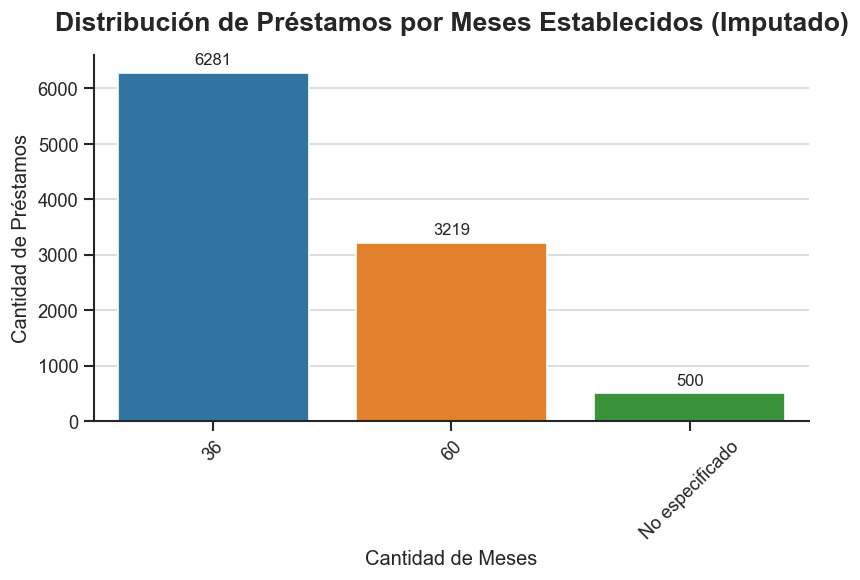

In [642]:
plot_grafico_barra(
    titulo='Distribución de Préstamos por Meses Establecidos (Imputado)',
    data_pandas=pandas_termino,
    cols=['data', 'count'],
    xlabel='Cantidad de Meses',
    ylabel='Cantidad de Préstamos'
)

#### *Estructura de los Datos Modificados*

In [645]:
pd.DataFrame(np.array(data_categoricos_codificados).transpose(), columns=etiquetas_categoricos_codificados).head(35)

,fecha_prestamo,estado_prestamo,riesgo_prestamo,clasificacion_estado_prestamo,duracion_prestamo_meses,duracion_prestamo_meses_imputados,duracion_prestamo_meses,duracion_prestamo_meses_imputados
0,5,Current,Bajo,1,36,36,36,36
1,0,Current,Bajo,1,36,36,36,36
2,9,Current,Bajo,1,36,36,36,36
3,7,Current,Bajo,1,36,36,36,36
4,8,Current,Bajo,1,36,36,36,36
5,10,Current,Bajo,1,60,60,60,60
6,9,Current,Bajo,1,60,60,60,60
7,4,Current,Bajo,1,36,36,36,36
8,11,Current,Bajo,1,36,36,36,36
9,11,Current,Bajo,1,36,36,36,36


Los datos se reorganizan de manera que cada elemento del arreglo corresponda a una de las columnas del conjunto de datos original. Esta transformación se realiza con el propósito de facilitar la identificación y el análisis de posibles valores erróneos, inconsistentes o atípicos presentes en los registros.

### **Categorías: grado y sub-grado**

## Segmentación de los Datos Crudos por Categoría

In [7]:
raw_data_copy = raw_data_np.copy()
caracteristicas_data = {}
for i in range(len(raw_data_copy[:,1:])):
    valores_unicos = np.unique(raw_data_copy[i,1:], return_counts=True)
    contenedor_temporal = []
    dict_temporal = {}
    for j in range(0,(len(valores_unicos)),2):
        contenedor_temporal = (valores_unicos[j], valores_unicos[j+1])
        for k in range(len(contenedor_temporal[0])):
            dict_temporal[contenedor_temporal[0][k]] = contenedor_temporal[1][k]
    caracteristicas_data[raw_data_copy[i,0]] = dict_temporal
label_data = [key for key, _ in caracteristicas_data.items()]
label_data

[np.str_('id'),
 np.str_('issue_d'),
 np.str_('loan_amnt'),
 np.str_('loan_status'),
 np.str_('funded_amnt'),
 np.str_('term'),
 np.str_('int_rate'),
 np.str_('installment'),
 np.str_('grade'),
 np.str_('sub_grade'),
 np.str_('verification_status'),
 np.str_('url'),
 np.str_('addr_state'),
 np.str_('total_pymnt')]

A partir de esta etapa se obtienen dos estructuras de datos:
- label_data: Contiene las etiquetas asociadas a cada una de las columnas de la base de datos.
- caracteristicas_data: Diccionario que resume las características de cada columna, incluyendo los valores únicos que la componen y la frecuencia de ocurrencia de cada uno de ellos. Esta información resulta útil para el análisis exploratorio de datos y la detección de posibles inconsistencias en los registros.

## Exploración de los valores por categoría

### **Categoría 'id'**

Esta categoría corresponde a los identificadores únicos asignados a cada registro de préstamo. 

Los valores contenidos en esta columna actúan como claves de identificación, garantizando la unicidad de cada observación dentro de la base de datos.

In [8]:
#caracteristicas_data[label_data[0]]
list(caracteristicas_data[label_data[0]].items())[:10]

[(np.str_('12606806'), np.int64(1)),
 (np.str_('13026045'), np.int64(1)),
 (np.str_('1312426'), np.int64(1)),
 (np.str_('14187903'), np.int64(1)),
 (np.str_('14428496'), np.int64(1)),
 (np.str_('14470171'), np.int64(1)),
 (np.str_('14550531'), np.int64(1)),
 (np.str_('14669896'), np.int64(1)),
 (np.str_('15389420'), np.int64(1)),
 (np.str_('16130931'), np.int64(1))]

In [9]:
arreglo_count = [item for _, item in caracteristicas_data[label_data[0]].items()]
max(arreglo_count)

np.int64(1)

El análisis de los identificadores presentes en la categoría 'id' evidencia que:

- Mantienen una correspondencia única con cada uno de los registros extraídos, por lo que pueden considerarse claves únicas dentro del conjunto de datos.
- Se descarta la presencia de registros duplicados, ya que cada identificador presenta una única ocurrencia en la base de datos analizada.
- Los identificadores proporcionados siguen una codificación consistente basada en un serial numérico. No obstante, debido a que su función es exclusivamente identificativa y no representan una variable cuantitativa, se considera apropiado preservarlos en formato de cadena de caracteres durante las etapas posteriores del procesamiento de datos.

### **Categoría 'issue_d'**

Esta categoría corresponde al mes en el que el préstamo fue financiado. Su contenido permite identificar el período temporal asociado a la formalización y desembolso de cada préstamo.

In [10]:
#caracteristicas_data[label_data[1]]
list(caracteristicas_data[label_data[1]].items())[:10]

[(np.str_(''), np.int64(500)),
 (np.str_('Apr-15'), np.int64(757)),
 (np.str_('Aug-15'), np.int64(846)),
 (np.str_('Dec-15'), np.int64(997)),
 (np.str_('Feb-15'), np.int64(530)),
 (np.str_('Jan-15'), np.int64(770)),
 (np.str_('Jul-15'), np.int64(1061)),
 (np.str_('Jun-15'), np.int64(654)),
 (np.str_('Mar-15'), np.int64(559)),
 (np.str_('May-15'), np.int64(741))]

Del análisis de los datos contenidos en la categoría 'issue_d' se observa lo siguiente:

- Los registros proporcionados corresponden a préstamos otorgados a lo largo del año 2015.
- No se identifican etiquetas diferentes que hagan referencia a un mismo mes.
- Se detectan 500 registros para los cuales el mes de otorgamiento no fue almacenado correctamente, apareciendo en la base de datos como una cadena vacía ('').

Recomendación: reemplazar las cadenas vacías ('') por el valor np.nan, con el fin de normalizar la representación de datos faltantes y facilitar su identificación, tratamiento y análisis posterior dentro de las estructuras de datos de NumPy.

### **Categoría 'loan_amnt'**

 Esta categoría representa el monto del préstamo solicitado por el prestatario. En caso de que el departamento de crédito haya realizado una reducción del monto inicialmente solicitado durante el proceso de evaluación, el valor registrado en esta variable corresponde al monto ajustado y finalmente aprobado.

In [11]:
#caracteristicas_data[label_data[2]]
list(caracteristicas_data[label_data[2]].items())[:10]

[(np.str_(''), np.int64(500)),
 (np.str_('1000.0'), np.int64(30)),
 (np.str_('10000.0'), np.int64(628)),
 (np.str_('10025.0'), np.int64(1)),
 (np.str_('10050.0'), np.int64(3)),
 (np.str_('10075.0'), np.int64(1)),
 (np.str_('10100.0'), np.int64(6)),
 (np.str_('10150.0'), np.int64(2)),
 (np.str_('10175.0'), np.int64(1)),
 (np.str_('10200.0'), np.int64(13))]

Del análisis de los datos contenidos en la categoría 'loan_amnt' se observa lo siguiente:

- Los registros proporcionados corresponden al monto de los préstamos asociados a cada solicitud contenida en la base de datos.
- Los valores almacenados representan cantidades numéricas y, por tanto, pueden ser tratados como datos de tipo flotante para facilitar su análisis y procesamiento.
- Se detectan 500 registros en los que el monto del préstamo no fue almacenado correctamente, encontrándose representado mediante una cadena vacía ('').
- No se identificaron valores con formatos atípicos o inconsistentes en comparación con el resto de los registros de esta categoría, lo que indica una adecuada uniformidad en la representación de los datos.

Recomendaciones:

- Reemplazar las cadenas vacías ('') por el valor np.nan, con el fin de normalizar la representación de datos faltantes y facilitar su identificación, tratamiento y análisis posterior.
- Convertir los valores válidos de la categoría desde cadenas de texto a un tipo de dato numérico (por ejemplo, float), permitiendo la aplicación de técnicas estadísticas y de análisis cuantitativo sobre esta variable.

### **Categoría 'loan_status'**

Categoría que contiene el estado actual del préstamo realizado.

In [12]:
#caracteristicas_data[label_data[3]]
list(caracteristicas_data[label_data[3]].items())[:10]

[(np.str_(''), np.int64(500)),
 (np.str_('Charged Off'), np.int64(61)),
 (np.str_('Current'), np.int64(8538)),
 (np.str_('Default'), np.int64(11)),
 (np.str_('Fully Paid'), np.int64(505)),
 (np.str_('In Grace Period'), np.int64(56)),
 (np.str_('Issued'), np.int64(184)),
 (np.str_('Late (16-30 days)'), np.int64(30)),
 (np.str_('Late (31-120 days)'), np.int64(115))]

Las categorías identificadas son las siguientes:

- Fully Paid: El préstamo fue liquidado en su totalidad.
- Issued: El préstamo ha sido aprobado y emitido recientemente.
- Current: El préstamo se encuentra activo y los pagos se realizan conforme a lo establecido.
- In Grace Period: El préstamo se encuentra dentro del período de gracia permitido para regularizar pagos atrasados.
- Default: El préstamo ha entrado en incumplimiento de pago.
- Late (16-30 days): El préstamo presenta un retraso en los pagos de entre 16 y 30 días. 
- Late (31-120 days): El préstamo presenta un retraso en los pagos de entre 31 y 120 días.
- Charged Off: El préstamo ha sido clasificado como incobrable por la entidad financiera.

Del análisis de los datos contenidos en la categoría 'loan_status' se observa lo siguiente:

- Los registros proporcionados describen el estado asociado a cada préstamo contenido en la base de datos.
- Los valores almacenados corresponden a categorías cualitativas y, por tanto, pueden ser representados mediante cadenas de texto.
- Se detectan 500 registros en los que el estado del préstamo no fue registrado adecuadamente, encontrándose representado mediante una cadena vacía ('').
- No se identificaron categorías redundantes, formatos inconsistentes ni etiquetas atípicas en comparación con el resto de los registros, lo que evidencia una adecuada uniformidad en la representación de los datos.

Recomendaciones:

- Reemplazar las cadenas vacías ('') por el valor np.nan, con el fin de normalizar la representación de datos faltantes y facilitar su identificación, tratamiento y análisis posterior.
- Considerar la creación de una categoría adicional que agrupe los estados asociados a incumplimiento o mora (por ejemplo, Default, Charged Off y categorías Late), en caso de que la variable vaya a emplearse posteriormente en tareas de análisis de riesgo o modelado predictivo.

### **Categoría 'funded_amnt'**

Esta categoría representa el monto total comprometido para el préstamo en el momento de su aprobación. El valor registrado puede diferir del monto inicialmente solicitado por el prestatario, ya que la entidad financiera puede realizar ajustes durante el proceso de evaluación crediticia. En consecuencia, esta variable refleja el importe efectivamente aprobado para el préstamo en el instante de su emisión.

In [13]:
#caracteristicas_data[label_data[4]]
list(caracteristicas_data[label_data[4]].items())[:10]

[(np.str_(''), np.int64(500)),
 (np.str_('1000.0'), np.int64(28)),
 (np.str_('10000.0'), np.int64(628)),
 (np.str_('10025.0'), np.int64(1)),
 (np.str_('10050.0'), np.int64(3)),
 (np.str_('10075.0'), np.int64(1)),
 (np.str_('10100.0'), np.int64(4)),
 (np.str_('10150.0'), np.int64(3)),
 (np.str_('10175.0'), np.int64(1)),
 (np.str_('10200.0'), np.int64(13))]

Del análisis de los datos contenidos en la categoría 'loan_amnt' se observa lo siguiente:

- Los registros proporcionados corresponden al monto de los préstamos aceptados que se encuentran asociados a cada solicitud contenida en la base de datos.
- Los valores almacenados representan cantidades numéricas y, por tanto, pueden ser tratados como datos de tipo flotante para facilitar su análisis y procesamiento.
- Se detectan 500 registros en los que el monto del préstamo no fue almacenado correctamente, encontrándose representado mediante una cadena vacía ('').
- No se identificaron valores con formatos atípicos o inconsistentes en comparación con el resto de los registros de esta categoría, lo que indica una adecuada uniformidad en la representación de los datos.

Recomendaciones:

- Reemplazar las cadenas vacías ('') por el valor np.nan, con el fin de normalizar la representación de datos faltantes y facilitar su identificación, tratamiento y análisis posterior.
- Convertir los valores válidos de la categoría desde cadenas de texto a un tipo de dato numérico (por ejemplo, float), permitiendo la aplicación de técnicas estadísticas y de análisis cuantitativo sobre esta variable.

### **Categoría 'term'**

Esta categoría indica el plazo de amortización del préstamo, expresado en meses. 

Los valores posibles son 36 y 60 meses, correspondientes a los dos esquemas de financiamiento ofrecidos para los préstamos registrados en la base de datos. 

Esta variable permite identificar el horizonte temporal establecido para la liquidación de cada préstamo.

In [14]:
#caracteristicas_data[label_data[5]]
list(caracteristicas_data[label_data[5]].items())[:10]

[(np.str_(''), np.int64(500)),
 (np.str_(' 36 months'), np.int64(6281)),
 (np.str_(' 60 months'), np.int64(3219))]

Del análisis de los datos contenidos en la categoría 'term' se observa lo siguiente:

- Los registros proporcionados corresponden al plazo de amortización asociado a cada préstamo, expresado en meses.
- Los valores almacenados representan cantidades numéricas discretas y, por tanto, pueden ser tratados como datos de tipo entero. No obstante, es necesario eliminar la unidad de medida ("months") para facilitar su procesamiento y análisis.
- Se detectan 500 registros cuyos plazos no fueron almacenados correctamente, encontrándose representados mediante una cadena vacía ('').
- No se identificaron valores con formatos atípicos o inconsistentes en comparación con el resto de los registros de esta categoría, lo que evidencia una adecuada uniformidad en la representación de los datos.
- Los únicos plazos observados en los registros válidos corresponden a 36 y 60 meses.

Recomendaciones:

- Reemplazar las cadenas vacías ('') por el valor np.nan, con el fin de normalizar la representación de datos faltantes y facilitar su identificación, tratamiento y análisis posterior.
- Eliminar la unidad de medida ("months") y convertir los valores válidos de la categoría desde cadenas de texto a un tipo de dato numérico entero (int).
- En caso de requerirse una representación más descriptiva de la información, conservar la unidad de medida mediante la documentación de la variable o la generación de una columna derivada para fines de presentación.

### **Categoría 'int_rate'**

Datos que se corresponden con la tasa de interés asociada al préstamo concedido al solicitante, expresada como un porcentaje sobre el monto financiado.

In [15]:
#caracteristicas_data[label_data[6]]
list(caracteristicas_data[label_data[6]].items())[:10]

[(np.str_(''), np.int64(500)),
 (np.str_('12.ìàé'), np.int64(48)),
 (np.str_('13.18'), np.int64(100)),
 (np.str_('13.33'), np.int64(418)),
 (np.str_('13.44'), np.int64(10)),
 (np.str_('13.66'), np.int64(56)),
 (np.str_('13.67'), np.int64(111)),
 (np.str_('13.99'), np.int64(402)),
 (np.str_('14.31'), np.int64(50)),
 (np.str_('14.33'), np.int64(33))]

In [16]:
valores_invalidos_rate = []
for key, _ in caracteristicas_data[label_data[6]].items():
    try:
        x = float(key)
    except:
        valores_invalidos_rate.append(key)
valores_invalidos_rate[:10]

[np.str_(''),
 np.str_('12.ìàé'),
 np.str_('18.ôåâ'),
 np.str_('24.ìàé'),
 np.str_('25.àâã'),
 np.str_('26.þíè'),
 np.str_('6.ìàð'),
 np.str_('9.àâã'),
 np.str_('àâã.18'),
 np.str_('àâã.19')]

Del análisis de los datos contenidos en la categoría 'int_rate' se observa lo siguiente:

- Los registros proporcionados corresponden a las tasas de interés establecidas a cada préstamo, expresada en porcentaje.
- Los valores almacenados representan cantidades numéricas y, por tanto, pueden ser tratados como datos de tipo flotante.
- Se detectan 500 registros cuyas tasas de interés no fueron almacenados correctamente, encontrándose representados mediante una cadena vacía ('').
- Se identificaron valores con formatos atípicos o inconsistentes en comparación con el resto de los registros de esta categoría, los cuales fueron agrupados dentro del arreglo valores_invalidos_rate.

Recomendaciones:

- Reemplazar las cadenas vacías ('') y los valores atípicos identificados por el valor np.nan, con el fin de normalizar la representación de datos faltantes y facilitar su identificación, tratamiento y análisis posterior.

### **Categoría 'installment'**

En esta categoría se agrega el pago mensual que deberá realizar el prestatario en caso de que el préstamo sea otorgado.

In [17]:
#caracteristicas_data[label_data[7]]
list(caracteristicas_data[label_data[7]].items())[:10]

[(np.str_(''), np.int64(500)),
 (np.str_('100.04'), np.int64(1)),
 (np.str_('100.06'), np.int64(6)),
 (np.str_('100.21'), np.int64(1)),
 (np.str_('100.5'), np.int64(1)),
 (np.str_('100.64'), np.int64(11)),
 (np.str_('100.68'), np.int64(1)),
 (np.str_('1000.37'), np.int64(1)),
 (np.str_('1000.59'), np.int64(4)),
 (np.str_('1001.15'), np.int64(3))]

Del análisis de los datos contenidos en la categoría 'installment' se observa lo siguiente:

- Los registros proporcionados corresponden al pago mensual que debe efectuar cada cliente.
- Los valores almacenados representan cantidades numéricas y, por tanto, pueden ser tratados como datos de tipo flotante para facilitar su análisis y procesamiento.
- Se detectan 500 registros en los que el monto del préstamo no fue almacenado correctamente, encontrándose representado mediante una cadena vacía ('').
- No se identificaron valores con formatos atípicos o inconsistentes en comparación con el resto de los registros de esta categoría, lo que indica una adecuada uniformidad en la representación de los datos.

Recomendaciones:

- Reemplazar las cadenas vacías ('') por el valor np.nan, con el fin de normalizar la representación de datos faltantes y facilitar su identificación, tratamiento y análisis posterior.
- Convertir los valores válidos de la categoría desde cadenas de texto a un tipo de dato numérico (por ejemplo, float), permitiendo la aplicación de técnicas estadísticas y de análisis cuantitativo sobre esta variable.

### **Categoría 'grade'**

Calificación del préstamo asignada por Lending Club (LC).

In [18]:
#caracteristicas_data[label_data[8]]
list(caracteristicas_data[label_data[8]].items())[:10]

[(np.str_(''), np.int64(515)),
 (np.str_('A'), np.int64(1632)),
 (np.str_('B'), np.int64(2606)),
 (np.str_('C'), np.int64(2766)),
 (np.str_('D'), np.int64(1389)),
 (np.str_('E'), np.int64(816)),
 (np.str_('F'), np.int64(236)),
 (np.str_('G'), np.int64(40))]

Los registros contenidos en esta categoría corresponden a la calificación crediticia asignada al préstamo por la entidad financiera. Dicha calificación se expresa mediante categorías ordenadas de la letra A a la G, donde las categorías más cercanas a A representan un menor nivel de riesgo crediticio, mientras que las categorías próximas a G indican un mayor riesgo asociado al préstamo.

Del análisis de los datos contenidos en la categoría 'grade' se observa lo siguiente:

- Los registros proporcionados describen la clasificación de cada uno de los préstamos efectuados por la entidad.
- Los valores almacenados corresponden a categorías cualitativas y, por tanto, pueden ser representados mediante cadenas de texto.
- Se detectan 515 registros en los que la categoría no está definida de manera adecuada, encontrándose representado mediante una cadena vacía ('').
- No se identificaron categorías redundantes, formatos inconsistentes ni etiquetas atípicas en comparación con el resto de los registros, lo que evidencia una adecuada uniformidad en la representación de los datos.

Recomendaciones:

- Reemplazar las cadenas vacías ('') por el valor np.nan, con el fin de normalizar la representación de datos faltantes y facilitar su identificación, tratamiento y análisis posterior.

### **Categoría 'sub_grade'**

Calificación del préstamo asignada por Lending Club (LC). (clasificación basada en sub-grados)

In [19]:
#caracteristicas_data[label_data[9]]
list(caracteristicas_data[label_data[9]].items())[:10]

[(np.str_(''), np.int64(514)),
 (np.str_('A1'), np.int64(285)),
 (np.str_('A2'), np.int64(278)),
 (np.str_('A3'), np.int64(239)),
 (np.str_('A4'), np.int64(323)),
 (np.str_('A5'), np.int64(502)),
 (np.str_('B1'), np.int64(509)),
 (np.str_('B2'), np.int64(517)),
 (np.str_('B3'), np.int64(530)),
 (np.str_('B4'), np.int64(553))]

Esta variable representa la subcalificación crediticia asignada al préstamo por la entidad financiera. La clasificación se expresa mediante una combinación de una letra y un número, donde la letra identifica la categoría general de riesgo y el número establece una graduación más específica dentro de dicha categoría. Esta variable permite una caracterización más detallada del perfil de riesgo asociado al préstamo.

Del análisis de los datos contenidos en la categoría 'sub_grade' se observa lo siguiente:

- Los registros proporcionados describen la clasificación de cada uno de los préstamos efectuados por la entidad por medio de sub-grados identificados por la asignación numérica de la clasificación.
- Los valores almacenados corresponden a categorías cualitativas y, por tanto, pueden ser representados mediante cadenas de texto.
- Se detectan 514 registros en los que la categoría no está definida de manera adecuada, encontrándose representado mediante una cadena vacía ('').
- No se identificaron categorías redundantes, formatos inconsistentes ni etiquetas atípicas en comparación con el resto de los registros, lo que evidencia una adecuada uniformidad en la representación de los datos.

Recomendaciones:

- Reemplazar las cadenas vacías ('') por el valor np.nan, con el fin de normalizar la representación de datos faltantes y facilitar su identificación, tratamiento y análisis posterior.

### **Categoría 'verification_status'**

Indica el estado de verificación de los ingresos declarados por el solicitante, especificando si dichos ingresos fueron verificados por la entidad financiera, no fueron verificados o si únicamente se verificó la fuente de ingresos.

In [20]:
#caracteristicas_data[label_data[10]]
list(caracteristicas_data[label_data[10]].items())[:10]

[(np.str_(''), np.int64(500)),
 (np.str_('Not Verified'), np.int64(2673)),
 (np.str_('Source Verified'), np.int64(4116)),
 (np.str_('Verified'), np.int64(2711))]

Los registros contenidos en esta categoría corresponden al estado de verificación de los ingresos declarados por el prestatario durante el proceso de solicitud del préstamo. En particular, la variable distingue entre ingresos no verificados (Not Verified), ingresos cuya fuente fue verificada (Source Verified) e ingresos completamente verificados por la entidad financiera (Verified).

Del análisis de los datos contenidos en la categoría 'verification_status' se observa lo siguiente:

- Los registros proporcionados describen el estado de verificación de los ingresos del cliente que solicitó el préstamo a la entidad.
- Los valores almacenados corresponden a categorías cualitativas y, por tanto, pueden ser representados mediante cadenas de texto.
- Se detectan 500 registros en los que la categoría no está definida de manera adecuada, encontrándose representado mediante una cadena vacía ('').
- No se identificaron categorías redundantes, formatos inconsistentes ni etiquetas atípicas en comparación con el resto de los registros, lo que evidencia una adecuada uniformidad en la representación de los datos.

Recomendaciones:

- Reemplazar las cadenas vacías ('') por el valor np.nan, con el fin de normalizar la representación de datos faltantes y facilitar su identificación, tratamiento y análisis posterior.

### **Categoría 'url'**

URL de la página de Lending Club que contiene la información asociada a la solicitud o publicación del préstamo.

In [21]:
#caracteristicas_data[label_data[11]]
list(caracteristicas_data[label_data[11]].items())[:10]

[(np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=12606806'),
  np.int64(1)),
 (np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=13026045'),
  np.int64(1)),
 (np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=1312426'),
  np.int64(1)),
 (np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=14187903'),
  np.int64(1)),
 (np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=14428496'),
  np.int64(1)),
 (np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=14470171'),
  np.int64(1)),
 (np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=14550531'),
  np.int64(1)),
 (np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=14669896'),
  np.int64(1)),
 (np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=15389420'),
  np.int64(1)),
 (np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=16130931'),
  np.int64(1))]

In [22]:
arreglo_count = [item for _, item in caracteristicas_data[label_data[11]].items()]
max(arreglo_count)

np.int64(1)

El análisis de las direcciones contenidas en la categoría 'url' evidencia que:

- Mantienen una correspondencia única con cada uno de los registros extraídos, por lo que pueden considerarse direcciones electrónicas únicas dentro del conjunto de datos, mediante las cuales se extrajeron los datos que fueron registrados.
- Se descarta la presencia de registros duplicados, ya que cada dirección posee una única ocurrencia en la base de datos analizada.

### **Categoría 'addr_state'**

El estado (entidad federativa) reportado por el prestatario en la solicitud del préstamo.

In [23]:
#caracteristicas_data[label_data[12]]
list(caracteristicas_data[label_data[12]].items())[:10]

[(np.str_(''), np.int64(500)),
 (np.str_('AK'), np.int64(26)),
 (np.str_('AL'), np.int64(119)),
 (np.str_('AR'), np.int64(74)),
 (np.str_('AZ'), np.int64(220)),
 (np.str_('CA'), np.int64(1336)),
 (np.str_('CO'), np.int64(201)),
 (np.str_('CT'), np.int64(143)),
 (np.str_('DC'), np.int64(27)),
 (np.str_('DE'), np.int64(27))]

Los registros contenidos en esta categoría corresponden al estado de residencia declarado por el prestatario durante el proceso de solicitud del préstamo. La información se encuentra representada mediante abreviaturas oficiales de los estados y territorios de los Estados Unidos, por lo que la variable proporciona una referencia geográfica asociada a cada solicitante.

Del análisis de los datos contenidos en la categoría 'addr_state' se observa lo siguiente:

- Los registros proporcionados describen el estado de la persona que solicitó el préstamo.
- Los valores almacenados corresponden a categorías cualitativas y, por tanto, pueden ser representados mediante cadenas de texto.
- Se detectan 500 registros en los que la categoría no está definida de manera adecuada, encontrándose representado mediante una cadena vacía ('').
- No se identificaron categorías redundantes, formatos inconsistentes ni etiquetas atípicas en comparación con el resto de los registros, lo que evidencia una adecuada uniformidad en la representación de los datos.

Recomendaciones:

- Reemplazar las cadenas vacías ('') por el valor np.nan, con el fin de normalizar la representación de datos faltantes y facilitar su identificación, tratamiento y análisis posterior.

### **Categoría 'total_pymnt'**

Representa el monto acumulado que el prestatario ha reembolsado hasta la fecha respecto al capital financiado, incluyendo los pagos efectuados durante la vigencia del préstamo.

In [24]:
#caracteristicas_data[label_data[13]]
list(caracteristicas_data[label_data[13]].items())[:10]

[(np.str_(''), np.int64(500)),
 (np.str_('0.0'), np.int64(384)),
 (np.str_('0.74'), np.int64(1)),
 (np.str_('100.0'), np.int64(1)),
 (np.str_('1000.62'), np.int64(1)),
 (np.str_('1000.81'), np.int64(2)),
 (np.str_('10002.6'), np.int64(1)),
 (np.str_('10006.27'), np.int64(1)),
 (np.str_('1001.69'), np.int64(1)),
 (np.str_('1001.71'), np.int64(1))]

Los registros contenidos en esta categoría corresponden al pago efectuado por los clientes en el momento en el cual se realizó la recopilación de los datos.

Del análisis de los datos contenidos en la categoría 'total_pymnt' se observa lo siguiente:

- Los registros proporcionados describen el pago efectuado por los clientes.
- Los valores almacenados corresponden a categorías cuantitativas y, por tanto, pueden ser representados mediante valores de punto flotante.
- Se detectan 500 registros en los que la categoría no está definida de manera adecuada, encontrándose representado mediante una cadena vacía ('').
- No se identificaron categorías redundantes, formatos inconsistentes ni etiquetas atípicas en comparación con el resto de los registros, lo que evidencia una adecuada uniformidad en la representación de los datos.

Recomendaciones:

- Reemplazar las cadenas vacías ('') por el valor np.nan, con el fin de normalizar la representación de datos faltantes y facilitar su identificación, tratamiento y análisis posterior.

## Casteo de datos

In [25]:
raw_data_copy = raw_data_np.copy()
casted_data_np = np.empty_like(raw_data_copy[:,1:], dtype=object)

for i in range(raw_data_np.shape[0]):
    for j in range(1, raw_data_np.shape[1]):
        try:
            if raw_data_copy[i, 0] != 'id':
                casted_data_np[i, j-1] = float(raw_data_copy[i, j])
            else:
                casted_data_np[i, j-1] = raw_data_copy[i, j]
        except ValueError:
            casted_data_np[i, j-1] = raw_data_copy[i, j]
casted_data_np[:,:3]

array([[np.str_('48010226'), np.str_('57693261'), np.str_('59432726')],
       [np.str_('May-15'), np.str_(''), np.str_('Sep-15')],
       [35000.0, 30000.0, 15000.0],
       [np.str_('Current'), np.str_('Current'), np.str_('Current')],
       [35000.0, 30000.0, 15000.0],
       [np.str_(' 36 months'), np.str_(' 36 months'), np.str_(' 36 months')],
       [13.33, np.str_('þëè.89'), np.str_('íîå.53')],
       [1184.86, 938.57, 494.86],
       [np.str_('C'), np.str_('A'), np.str_('B')],
       [np.str_('C3'), np.str_('A5'), np.str_('B5')],
       [np.str_('Verified'), np.str_('Source Verified'), np.str_('Verified')],
       [np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=48010226'),
        np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=57693261'),
        np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=59432726')],
       [np.str_('CA'), np.str_('NY'), np.str_('PA')],
       [9452.96, 4679.7, 1969.83]], dtype=object)

## Definición y Corrección de la Estructura de Datos

### **Estructuración del diccionario de categorías**

In [26]:
data_dict = {}
for i in range(len(raw_data_np[:,0])):
    data_dict[raw_data_np[i,0]] = casted_data_np[i]

### **Corrección de los elementos integrados a la categoría 'issue_d'**

In [27]:
data_dict['issue_d'] = np.where(
    data_dict['issue_d'] == '',
    np.nan,
    data_dict['issue_d']
)
registros_faltantes = np.sum(pd.isna(data_dict['issue_d']))
print(registros_faltantes)

500


In [28]:
total_registros = np.size(data_dict['issue_d'])
pct_b = registros_faltantes/total_registros*100
print(pct_b)

5.0


Se llevó a cabo la corrección de los registros contenidos en la categoría 'issue_d', reemplazando las etiquetas vacías ('') por el valor np.nan, con el propósito de estandarizar la representación de datos faltantes dentro de la estructura de datos.

Posteriormente, se calculó la proporción de valores faltantes respecto al total de registros disponibles, obteniéndose un porcentaje del 5 %. Este resultado indica que la completitud de la información asociada a esta variable es elevada, aunque la presencia de datos faltantes deberá considerarse durante las etapas posteriores de análisis y preprocesamiento.

### **Corrección de los elementos integrados a la categoría 'loan_amnt'**

In [29]:
data_dict['loan_amnt'] = np.where(
    data_dict['loan_amnt'] == '',
    np.nan,
    data_dict['loan_amnt']
)
registros_faltantes = np.sum(pd.isna(data_dict['loan_amnt']))
print(registros_faltantes)

500


In [30]:
total_registros = np.size(data_dict['loan_amnt'])
pct_b = registros_faltantes/total_registros*100
print(pct_b)

5.0


Se llevó a cabo la corrección de los registros contenidos en la categoría 'loan_amnt', reemplazando las etiquetas vacías ('') por el valor np.nan, con el propósito de estandarizar la representación de datos faltantes dentro de la estructura de datos.

Posteriormente, se calculó la proporción de valores faltantes respecto al total de registros disponibles, obteniéndose un porcentaje del 5 %. Este resultado indica que la completitud de la información asociada a esta variable es elevada, aunque la presencia de datos faltantes deberá considerarse durante las etapas posteriores de análisis y preprocesamiento.

### Corrección de los elementos integrados a la categoría 'loan_status'

In [31]:
data_dict['loan_status'] = np.where(
    data_dict['loan_status'] == '',
    np.nan,
    data_dict['loan_status']
)
registros_faltantes = np.sum(pd.isna(data_dict['loan_status']))
print(registros_faltantes)

500


In [32]:
total_registros = np.size(data_dict['loan_status'])
pct_b = registros_faltantes/total_registros*100
print(pct_b)

5.0


Se llevó a cabo la corrección de los registros contenidos en la categoría 'loan_status', reemplazando las etiquetas vacías ('') por el valor np.nan, con el propósito de estandarizar la representación de datos faltantes dentro de la estructura de datos.

Posteriormente, se calculó la proporción de valores faltantes respecto al total de registros disponibles, obteniéndose un porcentaje del 5 %. Este resultado indica que la completitud de la información asociada a esta variable es elevada, aunque la presencia de datos faltantes deberá considerarse durante las etapas posteriores de análisis y preprocesamiento.

### Corrección de los elementos integrados a la categoría 'funded_amnt'

In [33]:
data_dict['funded_amnt'] = np.where(
    data_dict['funded_amnt'] == '',
    np.nan,
    data_dict['funded_amnt']
)
registros_faltantes = np.sum(pd.isna(data_dict['funded_amnt']))
print(registros_faltantes)

500


In [34]:
total_registros = np.size(data_dict['funded_amnt'])
pct_b = registros_faltantes/total_registros*100
print(pct_b)

5.0


Se llevó a cabo la corrección de los registros contenidos en la categoría 'funded_amnt', reemplazando las etiquetas vacías ('') por el valor np.nan, con el propósito de estandarizar la representación de datos faltantes dentro de la estructura de datos.

Posteriormente, se calculó la proporción de valores faltantes respecto al total de registros disponibles, obteniéndose un porcentaje del 5 %. Este resultado indica que la completitud de la información asociada a esta variable es elevada, aunque la presencia de datos faltantes deberá considerarse durante las etapas posteriores de análisis y preprocesamiento.

### Corrección de los elementos integrados a la categoría 'term'

In [35]:
for i in range(len(data_dict['term'])):
    if data_dict['term'][i] != "":
        data_dict['term'][i] = int((data_dict['term'][i].split()[0]))
    else:
        data_dict['term'][i] = np.nan
type(data_dict['term'])

numpy.ndarray

In [37]:
registros_faltantes = np.sum(pd.isna(data_dict['term']))
print(registros_faltantes)

500


In [38]:
total_registros = np.size(data_dict['term'])
pct_b = registros_faltantes/total_registros*100
print(pct_b)

5.0


Se llevaron a cabo dos procesos de transformación sobre los datos contenidos en esta categoría:

- Los registros válidos fueron convertidos a valores enteros, ya que representan la cantidad de meses correspondiente al plazo del préstamo otorgado.
- Los registros vacíos fueron reemplazados por valores np.nan con el fin de identificar explícitamente los datos faltantes.

Posteriormente, se calculó la proporción de valores faltantes respecto al total de registros disponibles, obteniéndose un porcentaje del 5 %. Este resultado evidencia un alto nivel de completitud en la información asociada a esta variable. No obstante, la presencia de datos faltantes deberá ser considerada en las etapas posteriores de preprocesamiento y análisis para garantizar la validez de los resultados obtenidos.

### Corrección de los elementos integrados a la categoría 'int_rate'

In [39]:
data_dict['int_rate'] = np.where(
    np.isin(data_dict['int_rate'], valores_invalidos_rate),
    np.nan,
    data_dict['int_rate']
)
registros_faltantes = np.sum(pd.isna(data_dict['int_rate']))
print(registros_faltantes)

6004


In [40]:
total_registros = np.size(data_dict['int_rate'])
pct_b = registros_faltantes/total_registros*100
print(pct_b)

60.040000000000006


Se llevó a cabo un proceso de depuración de los datos registrados en esta categoría, encontrándose que el 60.04 % de los registros presentaban un formato inadecuado. Este resultado evidencia una baja calidad de los datos asociados a la variable, lo que dificulta la aplicación de procedimientos de corrección sin introducir un sesgo significativo en los resultados o comprometer la representatividad de la información original.

En consecuencia, se determinó que los datos contenidos en esta columna no poseen la confiabilidad necesaria para ser considerados en etapas posteriores del análisis. Por ello, la variable fue descartada del estudio, imposibilitando la evaluación de aspectos como la influencia de la tasa de interés sobre la capacidad o voluntad de pago de los clientes de la institución financiera.

### Corrección de los elementos integrados a la categoría 'installment'

In [41]:
data_dict['installment'] = np.where(
    data_dict['installment'] == '',
    np.nan,
    data_dict['installment']
)
registros_faltantes = np.sum(pd.isna(data_dict['installment']))
print(registros_faltantes)

500


In [42]:
total_registros = np.size(data_dict['int_rate'])
pct_b = registros_faltantes/total_registros*100
print(pct_b)

5.0


Se llevó a cabo la corrección de los registros contenidos en la categoría 'installment', reemplazando las etiquetas vacías ('') por el valor np.nan, con el propósito de estandarizar la representación de datos faltantes dentro de la estructura de datos.

Posteriormente, se calculó la proporción de valores faltantes respecto al total de registros disponibles, obteniéndose un porcentaje del 5 %. Este resultado indica que la completitud de la información asociada a esta variable es elevada, aunque la presencia de datos faltantes deberá considerarse durante las etapas posteriores de análisis y preprocesamiento.

### Corrección de los elementos integrados a la categoría 'grade'

In [43]:
data_dict['grade'] = np.where(
    data_dict['grade'] == '',
    np.nan,
    data_dict['grade']
)
registros_faltantes = np.sum(pd.isna(data_dict['grade']))
print(registros_faltantes)

515


In [44]:
total_registros = np.size(data_dict['grade'])
pct_b = registros_faltantes/total_registros*100
print(pct_b)

5.1499999999999995


Se llevó a cabo la corrección de los registros contenidos en la categoría 'installment', reemplazando las etiquetas vacías ('') por el valor np.nan, con el propósito de estandarizar la representación de datos faltantes dentro de la estructura de datos.

Posteriormente, se calculó la proporción de valores faltantes respecto al total de registros disponibles, obteniéndose un porcentaje del 5.15 %. Este resultado indica que la completitud de la información asociada a esta variable es elevada, aunque la presencia de datos faltantes deberá considerarse durante las etapas posteriores de análisis y preprocesamiento.

### Corrección de los elementos integrados a la categoría 'sub_grade'

In [45]:
data_dict['sub_grade'] = np.where(
    data_dict['sub_grade'] == '',
    np.nan,
    data_dict['sub_grade']
)
registros_faltantes = np.sum(pd.isna(data_dict['sub_grade']))
print(registros_faltantes)

514


In [46]:
total_registros = np.size(data_dict['sub_grade'])
pct_b = registros_faltantes/total_registros*100
print(pct_b)

5.140000000000001


Se llevó a cabo la corrección de los registros contenidos en la categoría 'installment', reemplazando las etiquetas vacías ('') por el valor np.nan, con el propósito de estandarizar la representación de datos faltantes dentro de la estructura de datos.

Posteriormente, se calculó la proporción de valores faltantes respecto al total de registros disponibles, obteniéndose un porcentaje del 5.14 %. Este resultado indica que la completitud de la información asociada a esta variable es elevada, aunque la presencia de datos faltantes deberá considerarse durante las etapas posteriores de análisis y preprocesamiento.

### Corrección de los elementos integrados a la categoría 'verification_status'

In [47]:
data_dict['verification_status'] = np.where(
    data_dict['verification_status'] == '',
    np.nan,
    data_dict['verification_status']
)
registros_faltantes = np.sum(pd.isna(data_dict['verification_status']))
print(registros_faltantes)

500


In [48]:
total_registros = np.size(data_dict['verification_status'])
pct_b = registros_faltantes/total_registros*100
print(pct_b)

5.0


Se llevó a cabo la corrección de los registros contenidos en la categoría 'verification_status', reemplazando las etiquetas vacías ('') por el valor np.nan, con el propósito de estandarizar la representación de datos faltantes dentro de la estructura de datos.

Posteriormente, se calculó la proporción de valores faltantes respecto al total de registros disponibles, obteniéndose un porcentaje del 5.00 %. Este resultado indica que la completitud de la información asociada a esta variable es elevada, aunque la presencia de datos faltantes deberá considerarse durante las etapas posteriores de análisis y preprocesamiento.

### Corrección de los elementos integrados a la categoría 'addr_state'

In [49]:
data_dict['addr_state'] = np.where(
    data_dict['addr_state'] == '',
    np.nan,
    data_dict['addr_state']
)
registros_faltantes = np.sum(pd.isna(data_dict['addr_state']))
print(registros_faltantes)

500


In [50]:
total_registros = np.size(data_dict['addr_state'])
pct_b = registros_faltantes/total_registros*100
print(pct_b)

5.0


Se llevó a cabo la corrección de los registros contenidos en la categoría 'verification_status', reemplazando las etiquetas vacías ('') por el valor np.nan, con el propósito de estandarizar la representación de datos faltantes dentro de la estructura de datos.

Posteriormente, se calculó la proporción de valores faltantes respecto al total de registros disponibles, obteniéndose un porcentaje del 5.00 %. Este resultado indica que la completitud de la información asociada a esta variable es elevada, aunque la presencia de datos faltantes deberá considerarse durante las etapas posteriores de análisis y preprocesamiento.

### Corrección de los elementos integrados a la categoría 'total_pymnt'

In [51]:
data_dict['total_pymnt'] = np.where(
    data_dict['total_pymnt'] == '',
    np.nan,
    data_dict['total_pymnt']
)
registros_faltantes = np.sum(pd.isna(data_dict['total_pymnt']))
print(registros_faltantes)

500


In [52]:
total_registros = np.size(data_dict['total_pymnt'])
pct_b = registros_faltantes/total_registros*100
print(pct_b)

5.0


Se llevó a cabo la corrección de los registros contenidos en la categoría 'verification_status', reemplazando las etiquetas vacías ('') por el valor np.nan, con el propósito de estandarizar la representación de datos faltantes dentro de la estructura de datos.

Posteriormente, se calculó la proporción de valores faltantes respecto al total de registros disponibles, obteniéndose un porcentaje del 5.00 %. Este resultado indica que la completitud de la información asociada a esta variable es elevada, aunque la presencia de datos faltantes deberá considerarse durante las etapas posteriores de análisis y preprocesamiento.

### Generacion np.array con datos casteados y corregidos

In [53]:
temporary_array = []
for key, value in data_dict.items():
    temporary_array.append(value)
casted_corrected_data = np.array(temporary_array)
type(casted_corrected_data)
print(casted_corrected_data[:, :5])

[[np.str_('48010226') np.str_('57693261') np.str_('59432726') np.str_('53222800')
  np.str_('57803010')]
 [np.str_('May-15') nan np.str_('Sep-15') np.str_('Jul-15') np.str_('Aug-15')]
 [35000.0 30000.0 15000.0 9600.0 8075.0]
 [np.str_('Current') np.str_('Current') np.str_('Current') np.str_('Current') np.str_('Current')]
 [35000.0 30000.0 15000.0 9600.0 8075.0]
 [36 36 36 36 36]
 [13.33 nan nan nan 19.19]
 [1184.86 938.57 494.86 300.35 296.78]
 [np.str_('C') np.str_('A') np.str_('B') np.str_('A') nan]
 [np.str_('C3') np.str_('A5') np.str_('B5') np.str_('A5') np.str_('E3')]
 [np.str_('Verified') np.str_('Source Verified') np.str_('Verified') np.str_('Not Verified')
  np.str_('Source Verified')]
 [np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=48010226')
  np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=57693261')
  np.str_('https://www.lendingclub.com/browse/loanDetail.action?loan_id=59432726')
  np.str_('https://www.lendingclub.com/browse/lo

## Manejo de los Datos con Pandas

### Generación de la estrucutra de datos DataFrame

In [306]:
data_pandas = pd.DataFrame(casted_corrected_data.transpose(), columns=label_data)
data_pandas.head(10)

,id,issue_d,loan_amnt,loan_status,funded_amnt,term,int_rate,installment,grade,sub_grade,verification_status,url,addr_state,total_pymnt
0,48010226,May-15,35000.0,Current,35000.0,36,13.33,1184.86,C,C3,Verified,https://www.lendingclub.com/browse/loanDetail....,CA,9452.96
1,57693261,NaN,30000.0,Current,30000.0,36,NaN,938.57,A,A5,Source Verified,https://www.lendingclub.com/browse/loanDetail....,NY,4679.7
2,59432726,Sep-15,15000.0,Current,15000.0,36,NaN,494.86,B,B5,Verified,https://www.lendingclub.com/browse/loanDetail....,PA,1969.83
3,53222800,Jul-15,9600.0,Current,9600.0,36,NaN,300.35,A,A5,Not Verified,https://www.lendingclub.com/browse/loanDetail....,OH,1793.68
4,57803010,Aug-15,8075.0,Current,8075.0,36,19.19,296.78,NaN,E3,Source Verified,https://www.lendingclub.com/browse/loanDetail....,TX,1178.51
5,63398019,Oct-15,14400.0,Current,14400.0,60,13.99,334.99,NaN,C4,Not Verified,https://www.lendingclub.com/browse/loanDetail....,AL,681.17
6,60850626,Sep-15,NaN,Current,13000.0,60,24.99,381.5,F,F4,Source Verified,https://www.lendingclub.com/browse/loanDetail....,CA,1126.45
7,46816139,Apr-15,7500.0,Current,7500.0,36,13.33,253.9,C,C3,NaN,https://www.lendingclub.com/browse/loanDetail....,GA,2025.65
8,63918356,Nov-15,8000.0,Current,8000.0,36,NaN,250.29,A,A5,Source Verified,https://www.lendingclub.com/browse/loanDetail....,MA,497.07
9,63651616,Nov-15,7200.0,Current,7200.0,36,NaN,241.18,C,C2,NaN,https://www.lendingclub.com/browse/loanDetail....,TX,512.57


### Redefinición del formato del data frame

Cambio de nombre de columnas del data frame para una mejor interpretación de los datos contenidos. Eliminación de la columna url puesto que los datos contenidos no aportan elementos al análisis.

In [307]:
data_pandas = data_pandas.rename(columns={
    'issue_d': 'issue_date',
    'loan_amnt': 'loan_amount_USD',
    'funded_amnt': 'funded_amount_USD',
    'term' : 'term_months',
    'addr_state' : 'state_address',
    'total_pymnt' : 'total_payment_USD'
})
data_pandas.drop('url', axis=1, inplace=True)

In [308]:
data_pandas.head(20)

,id,issue_date,loan_amount_USD,loan_status,funded_amount_USD,term_months,int_rate,installment,grade,sub_grade,verification_status,state_address,total_payment_USD
0,48010226,May-15,35000.0,Current,35000.0,36,13.33,1184.86,C,C3,Verified,CA,9452.96
1,57693261,NaN,30000.0,Current,30000.0,36,NaN,938.57,A,A5,Source Verified,NY,4679.7
2,59432726,Sep-15,15000.0,Current,15000.0,36,NaN,494.86,B,B5,Verified,PA,1969.83
3,53222800,Jul-15,9600.0,Current,9600.0,36,NaN,300.35,A,A5,Not Verified,OH,1793.68
4,57803010,Aug-15,8075.0,Current,8075.0,36,19.19,296.78,NaN,E3,Source Verified,TX,1178.51
5,63398019,Oct-15,14400.0,Current,14400.0,60,13.99,334.99,NaN,C4,Not Verified,AL,681.17
6,60850626,Sep-15,NaN,Current,13000.0,60,24.99,381.5,F,F4,Source Verified,CA,1126.45
7,46816139,Apr-15,7500.0,Current,7500.0,36,13.33,253.9,C,C3,NaN,GA,2025.65
8,63918356,Nov-15,8000.0,Current,8000.0,36,NaN,250.29,A,A5,Source Verified,MA,497.07
9,63651616,Nov-15,7200.0,Current,7200.0,36,NaN,241.18,C,C2,NaN,TX,512.57


### Reorganización del data frame de acuerdo con el id registrado

Organización de los datos del data frame a partir del id registrado. Para eso se procede a convertir los elementos de esta categoría en variables del tipo entero

In [309]:
data_pandas['id'] = data_pandas['id'].astype(int)
data_pandas = data_pandas.sort_values(by='id').reset_index()
data_pandas.drop('index', axis=1, inplace=True)

In [310]:
data_pandas.head(20)

,id,issue_date,loan_amount_USD,loan_status,funded_amount_USD,term_months,int_rate,installment,grade,sub_grade,verification_status,state_address,total_payment_USD
0,373332,Oct-15,9950.0,Current,NaN,36,18.25,360.97,E,E1,Not Verified,CA,1072.82
1,575239,Oct-15,12000.0,Current,12000.0,60,20.99,324.58,E,NaN,Verified,MD,959.75
2,707689,Feb-15,10000.0,Current,10000.0,36,13.66,340.13,C,C3,Verified,NaN,3726.25
3,709828,Oct-15,27200.0,Current,27200.0,60,NaN,553.87,B,B1,Not Verified,PA,NaN
4,849994,Mar-15,11400.0,NaN,11400.0,36,NaN,376.09,B,B5,Not Verified,CA,3753.6
5,1312426,Apr-15,15000.0,Current,15000.0,60,15.61,361.67,D,D1,Source Verified,NY,2880.35
6,4526500,Apr-15,10800.0,Current,10800.0,36,NaN,328.22,A,A1,Source Verified,NC,2950.42
7,6736790,Jan-15,18000.0,Current,18000.0,60,NaN,370.78,B,B1,Verified,CA,4432.02
8,8138291,Feb-15,10350.0,Charged Off,NaN,60,22.99,291.72,F,F1,Verified,NY,1432.16
9,8214572,Feb-15,7000.0,Fully Paid,7000.0,36,NaN,233.81,C,C1,Source Verified,TN,7300.41


### Reconfiguración de los datos en la categoría loan_amount_USD

Se requiere de evaluar la correlación que existe entre los datos contenidos en la columna loan_amnt y funded_amnt

In [311]:
datos = data_pandas[['loan_amount_USD', 'funded_amount_USD']].dropna()
datos['loan_amount_USD'] = pd.to_numeric(datos['loan_amount_USD'], errors='coerce')
datos['funded_amount_USD'] = pd.to_numeric(datos['funded_amount_USD'], errors='coerce')
print(datos.dtypes)
r = np.corrcoef(datos['loan_amount_USD'], datos['funded_amount_USD'])
r

loan_amount_USD      float64
funded_amount_USD    float64
dtype: object


array([[1., 1.],
       [1., 1.]])

Se observa una correlación prácticamente perfecta entre las variables loan_amnt y funded_amnt. Por ello, los registros faltantes en la categoría loan_amnt podrían estimarse a partir de la información disponible en funded_amnt, con una baja probabilidad de introducir errores significativos, siempre que la relación observada se mantenga para los datos faltantes.

In [312]:
data_pandas['loan_amount_USD'] = data_pandas['loan_amount_USD'].fillna(
    data_pandas['funded_amount_USD']
)
data_pandas.drop('funded_amount_USD', axis=1, inplace=True)
print(pd.isna(data_pandas['loan_amount_USD']).sum())

0


In [313]:
data_pandas.head()

,id,issue_date,loan_amount_USD,loan_status,term_months,int_rate,installment,grade,sub_grade,verification_status,state_address,total_payment_USD
0,373332,Oct-15,9950.0,Current,36,18.25,360.97,E,E1,Not Verified,CA,1072.82
1,575239,Oct-15,12000.0,Current,60,20.99,324.58,E,NaN,Verified,MD,959.75
2,707689,Feb-15,10000.0,Current,36,13.66,340.13,C,C3,Verified,NaN,3726.25
3,709828,Oct-15,27200.0,Current,60,NaN,553.87,B,B1,Not Verified,PA,NaN
4,849994,Mar-15,11400.0,NaN,36,NaN,376.09,B,B5,Not Verified,CA,3753.6


Con la estrategia de imputación propuesta, se logró la reconstrucción completa de los valores faltantes en la columna loan_amnt. Dado que la variable funded_amnt no aporta información adicional relevante y presenta una redundancia significativa respecto a loan_amnt, se procedió a su eliminación del conjunto de datos.

### Redefinición del formato de la fecha

In [314]:
months = ['Void', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data_pandas['issue_date'] = data_pandas['issue_date'].fillna(
    'Void'
)
dates = data_pandas['issue_date'].value_counts().reset_index()
date_dict = {}
for i in dates['issue_date']:
    date_dict[i] = months.index(i.split('-')[0])
data_pandas['issue_date'] = data_pandas['issue_date'].str[:].map(date_dict)

In [315]:
data_pandas.head(10)

,id,issue_date,loan_amount_USD,loan_status,term_months,int_rate,installment,grade,sub_grade,verification_status,state_address,total_payment_USD
0,373332,10,9950.0,Current,36,18.25,360.97,E,E1,Not Verified,CA,1072.82
1,575239,10,12000.0,Current,60,20.99,324.58,E,NaN,Verified,MD,959.75
2,707689,2,10000.0,Current,36,13.66,340.13,C,C3,Verified,NaN,3726.25
3,709828,10,27200.0,Current,60,NaN,553.87,B,B1,Not Verified,PA,NaN
4,849994,3,11400.0,NaN,36,NaN,376.09,B,B5,Not Verified,CA,3753.6
5,1312426,4,15000.0,Current,60,15.61,361.67,D,D1,Source Verified,NY,2880.35
6,4526500,4,10800.0,Current,36,NaN,328.22,A,A1,Source Verified,NC,2950.42
7,6736790,1,18000.0,Current,60,NaN,370.78,B,B1,Verified,CA,4432.02
8,8138291,2,10350.0,Charged Off,60,22.99,291.72,F,F1,Verified,NY,1432.16
9,8214572,2,7000.0,Fully Paid,36,NaN,233.81,C,C1,Source Verified,TN,7300.41


### Redefinición del estado del préstamo

Para simplificar el análisis, el estado del préstamo se redefinirá de forma binaria en dos categorías principales:

Bueno (1): Incluye los estados Current, Fully Paid, In Grace Period, Issued y Late (16-30 days). Este último se considera favorable bajo la premisa de que el cliente aún se encuentra dentro de un periodo de latencia tolerable para efectuar su pago al recibir su salario.

Malo (0): Incluye los estados Charged-Off, Default y los retrasos mayores (Late de largo plazo).

Ante la presencia de registros faltantes o sin información, se adoptará una postura conservadora asignándoles el valor de Malo (0). El proceso de conversión se resolverá evaluando la pertenencia de los estados actuales dentro de un arreglo de referencia.

In [316]:
arreglo_buen_estado = ['Current', 'Fully Paid', 'In Grace Period', 'Issued', 'Late (16-30 days)']
data_pandas['loan_status'] = data_pandas['loan_status'].fillna(
    'Default'
)
status = data_pandas['loan_status'].value_counts().reset_index()
status_dict = {}
for i in status['loan_status']:
    if i in arreglo_buen_estado:
        status_dict[i] = 1
    else:
        status_dict[i] = 0
data_pandas['loan_status'] = data_pandas['loan_status'].str[:].map(status_dict)


In [317]:
data_pandas.head(10)

,id,issue_date,loan_amount_USD,loan_status,term_months,int_rate,installment,grade,sub_grade,verification_status,state_address,total_payment_USD
0,373332,10,9950.0,1,36,18.25,360.97,E,E1,Not Verified,CA,1072.82
1,575239,10,12000.0,1,60,20.99,324.58,E,NaN,Verified,MD,959.75
2,707689,2,10000.0,1,36,13.66,340.13,C,C3,Verified,NaN,3726.25
3,709828,10,27200.0,1,60,NaN,553.87,B,B1,Not Verified,PA,NaN
4,849994,3,11400.0,0,36,NaN,376.09,B,B5,Not Verified,CA,3753.6
5,1312426,4,15000.0,1,60,15.61,361.67,D,D1,Source Verified,NY,2880.35
6,4526500,4,10800.0,1,36,NaN,328.22,A,A1,Source Verified,NC,2950.42
7,6736790,1,18000.0,1,60,NaN,370.78,B,B1,Verified,CA,4432.02
8,8138291,2,10350.0,0,60,22.99,291.72,F,F1,Verified,NY,1432.16
9,8214572,2,7000.0,1,36,NaN,233.81,C,C1,Source Verified,TN,7300.41


In [318]:
pd.isna(data_pandas['loan_status']).sum()

np.int64(0)

Ante la presencia de un 5% de datos faltantes en la categoría loan_status, se optó por imputar dichos registros asignándoles un estado financiero "Malo". Esta decisión adopta una postura conservadora (el escenario más desfavorable) que introduce una subevaluación preventiva en el análisis. Dado el bajo porcentaje de registros afectados, el impacto de esta manipulación en las métricas predictivas o de evaluación futuras es mínimo.

### Redefinición del término del préstamo

Siguiendo la premisa establecida, se asume el escenario más desfavorable para la institución financiera en esta categoría, lo que se traduce en un préstamo con un plazo equivalente al máximo permitido dentro de los datos aportados.

In [319]:
data_pandas['term_months'] = data_pandas['term_months'].fillna(
    data_pandas['term_months'].max
)

In [320]:
data_pandas.head(10)

,id,issue_date,loan_amount_USD,loan_status,term_months,int_rate,installment,grade,sub_grade,verification_status,state_address,total_payment_USD
0,373332,10,9950.0,1,36,18.25,360.97,E,E1,Not Verified,CA,1072.82
1,575239,10,12000.0,1,60,20.99,324.58,E,NaN,Verified,MD,959.75
2,707689,2,10000.0,1,36,13.66,340.13,C,C3,Verified,NaN,3726.25
3,709828,10,27200.0,1,60,NaN,553.87,B,B1,Not Verified,PA,NaN
4,849994,3,11400.0,0,36,NaN,376.09,B,B5,Not Verified,CA,3753.6
5,1312426,4,15000.0,1,60,15.61,361.67,D,D1,Source Verified,NY,2880.35
6,4526500,4,10800.0,1,36,NaN,328.22,A,A1,Source Verified,NC,2950.42
7,6736790,1,18000.0,1,60,NaN,370.78,B,B1,Verified,CA,4432.02
8,8138291,2,10350.0,0,60,22.99,291.72,F,F1,Verified,NY,1432.16
9,8214572,2,7000.0,1,36,NaN,233.81,C,C1,Source Verified,TN,7300.41


In [321]:
pd.isna(data_pandas['term_months']).sum()

np.int64(0)

Ante la presencia de un 5% de datos faltantes en la variable term_months, se optó por imputar dichos registros asignándoles el plazo máximo observado en el resto de los datos de esta categoría. Esta decisión adopta una postura conservadora (el escenario más desfavorable) que introduce una subevaluación preventiva en el análisis. Dado el bajo porcentaje de registros afectados, se anticipa que el impacto de esta imputación en las métricas predictivas o de evaluación futuras será mínimo.

### Redefinición del término verificación de estado

Para este criterio de imputación, se asume que las omisiones en los registros equivalen a casos sin verificación previa. Adoptar esta postura permite reflejar el escenario más desfavorable (pesimista) en la evaluación de riesgo de la entidad financiera.

In [322]:
data_pandas['verification_status'] = data_pandas['verification_status'].fillna(
    'Not Verified'
)

In [323]:
data_pandas.head(10)

,id,issue_date,loan_amount_USD,loan_status,term_months,int_rate,installment,grade,sub_grade,verification_status,state_address,total_payment_USD
0,373332,10,9950.0,1,36,18.25,360.97,E,E1,Not Verified,CA,1072.82
1,575239,10,12000.0,1,60,20.99,324.58,E,NaN,Verified,MD,959.75
2,707689,2,10000.0,1,36,13.66,340.13,C,C3,Verified,NaN,3726.25
3,709828,10,27200.0,1,60,NaN,553.87,B,B1,Not Verified,PA,NaN
4,849994,3,11400.0,0,36,NaN,376.09,B,B5,Not Verified,CA,3753.6
5,1312426,4,15000.0,1,60,15.61,361.67,D,D1,Source Verified,NY,2880.35
6,4526500,4,10800.0,1,36,NaN,328.22,A,A1,Source Verified,NC,2950.42
7,6736790,1,18000.0,1,60,NaN,370.78,B,B1,Verified,CA,4432.02
8,8138291,2,10350.0,0,60,22.99,291.72,F,F1,Verified,NY,1432.16
9,8214572,2,7000.0,1,36,NaN,233.81,C,C1,Source Verified,TN,7300.41


In [324]:
pd.isna(data_pandas['verification_status']).sum()

np.int64(0)

Ante la presencia de un 5% de datos faltantes en la variable verification_status, se optó por imputar dichos registros asignándoles la condición de "No verificado". Esta decisión responde a un criterio de máxima prudencia, asumiendo el escenario más desfavorable para robustecer la evaluación de riesgo. Debido a la baja proporción de omisiones, se prevé que esta asignación no altere significativamente el rendimiento de las métricas predictivas o de evaluación futuras.

Se procede a realizar la codificación binaria de la variable verification_status. Bajo este esquema, la condición de "No verificado" se establece con el valor de cero (0), mientras que las categorías restantes presentes en el conjunto de datos se transforman al valor equivalente a la unidad (1).

In [325]:
arreglo_mala_verificacion = ['Not Verified']
status_verified = data_pandas['verification_status'].value_counts().reset_index()
verification_dict = {}
for i in status_verified['verification_status']:
    if i in arreglo_mala_verificacion:
        verification_dict[i] = 0
    else:
        verification_dict[i] = 1
data_pandas['verification_status'] = data_pandas['verification_status'].str[:].map(verification_dict)

In [326]:
data_pandas.head(10)

,id,issue_date,loan_amount_USD,loan_status,term_months,int_rate,installment,grade,sub_grade,verification_status,state_address,total_payment_USD
0,373332,10,9950.0,1,36,18.25,360.97,E,E1,0,CA,1072.82
1,575239,10,12000.0,1,60,20.99,324.58,E,NaN,1,MD,959.75
2,707689,2,10000.0,1,36,13.66,340.13,C,C3,1,NaN,3726.25
3,709828,10,27200.0,1,60,NaN,553.87,B,B1,0,PA,NaN
4,849994,3,11400.0,0,36,NaN,376.09,B,B5,0,CA,3753.6
5,1312426,4,15000.0,1,60,15.61,361.67,D,D1,1,NY,2880.35
6,4526500,4,10800.0,1,36,NaN,328.22,A,A1,1,NC,2950.42
7,6736790,1,18000.0,1,60,NaN,370.78,B,B1,1,CA,4432.02
8,8138291,2,10350.0,0,60,22.99,291.72,F,F1,1,NY,1432.16
9,8214572,2,7000.0,1,36,NaN,233.81,C,C1,1,TN,7300.41


### Redefinición del término sub-grade

Para mitigar la inconsistencia de datos en la variable sub_grade, los valores faltantes se imputarán a partir de la categoría principal grade. En los casos donde se requiera este llenado, se asignará por defecto la peor condición numérica (5). Esta acción se alinea con el criterio conservador previamente definido, reflejando el escenario de mayor riesgo posible para la institución financiera.

In [327]:
data_pandas['sub_grade'] = data_pandas['sub_grade'].fillna(
    (data_pandas['grade'].astype(str) + '5').where(data_pandas['grade'].notna())
)

In [328]:
data_pandas.head(10)

,id,issue_date,loan_amount_USD,loan_status,term_months,int_rate,installment,grade,sub_grade,verification_status,state_address,total_payment_USD
0,373332,10,9950.0,1,36,18.25,360.97,E,E1,0,CA,1072.82
1,575239,10,12000.0,1,60,20.99,324.58,E,E5,1,MD,959.75
2,707689,2,10000.0,1,36,13.66,340.13,C,C3,1,NaN,3726.25
3,709828,10,27200.0,1,60,NaN,553.87,B,B1,0,PA,NaN
4,849994,3,11400.0,0,36,NaN,376.09,B,B5,0,CA,3753.6
5,1312426,4,15000.0,1,60,15.61,361.67,D,D1,1,NY,2880.35
6,4526500,4,10800.0,1,36,NaN,328.22,A,A1,1,NC,2950.42
7,6736790,1,18000.0,1,60,NaN,370.78,B,B1,1,CA,4432.02
8,8138291,2,10350.0,0,60,22.99,291.72,F,F1,1,NY,1432.16
9,8214572,2,7000.0,1,36,NaN,233.81,C,C1,1,TN,7300.41


In [329]:
pd.isna(data_pandas['sub_grade']).sum()

np.int64(9)

Tras este procedimiento, los 9 registros remanentes que no pudieron ser imputados —debido a la ausencia simultánea de información en la variable grade— se resolvieron mediante una segunda etapa de imputación. En esta fase, se les asignó de forma directa una clasificación penalizada (G6), la cual se ubica deliberadamente por debajo de la peor condición de la escala estándar. Esta acción garantiza el cumplimiento estricto del enfoque conservador propuesto y aísla la incertidumbre absoluta en el escenario de mayor riesgo financiero posible.

In [330]:
data_pandas['sub_grade'] = data_pandas['sub_grade'].fillna(
    'G6'
)

In [331]:
data_pandas.head(10)

,id,issue_date,loan_amount_USD,loan_status,term_months,int_rate,installment,grade,sub_grade,verification_status,state_address,total_payment_USD
0,373332,10,9950.0,1,36,18.25,360.97,E,E1,0,CA,1072.82
1,575239,10,12000.0,1,60,20.99,324.58,E,E5,1,MD,959.75
2,707689,2,10000.0,1,36,13.66,340.13,C,C3,1,NaN,3726.25
3,709828,10,27200.0,1,60,NaN,553.87,B,B1,0,PA,NaN
4,849994,3,11400.0,0,36,NaN,376.09,B,B5,0,CA,3753.6
5,1312426,4,15000.0,1,60,15.61,361.67,D,D1,1,NY,2880.35
6,4526500,4,10800.0,1,36,NaN,328.22,A,A1,1,NC,2950.42
7,6736790,1,18000.0,1,60,NaN,370.78,B,B1,1,CA,4432.02
8,8138291,2,10350.0,0,60,22.99,291.72,F,F1,1,NY,1432.16
9,8214572,2,7000.0,1,36,NaN,233.81,C,C1,1,TN,7300.41


In [332]:
pd.isna(data_pandas['sub_grade']).sum()

np.int64(0)

La columna correspondiente a la categoría grade carece de sentido posterior a los procesos de imputación efectuados, por lo cual se procede a su eliminación dentro del data frame desarrollado

In [333]:
data_pandas.drop('grade', axis=1, inplace=True)

In [334]:
data_pandas.head(10)

,id,issue_date,loan_amount_USD,loan_status,term_months,int_rate,installment,sub_grade,verification_status,state_address,total_payment_USD
0,373332,10,9950.0,1,36,18.25,360.97,E1,0,CA,1072.82
1,575239,10,12000.0,1,60,20.99,324.58,E5,1,MD,959.75
2,707689,2,10000.0,1,36,13.66,340.13,C3,1,NaN,3726.25
3,709828,10,27200.0,1,60,NaN,553.87,B1,0,PA,NaN
4,849994,3,11400.0,0,36,NaN,376.09,B5,0,CA,3753.6
5,1312426,4,15000.0,1,60,15.61,361.67,D1,1,NY,2880.35
6,4526500,4,10800.0,1,36,NaN,328.22,A1,1,NC,2950.42
7,6736790,1,18000.0,1,60,NaN,370.78,B1,1,CA,4432.02
8,8138291,2,10350.0,0,60,22.99,291.72,F1,1,NY,1432.16
9,8214572,2,7000.0,1,36,NaN,233.81,C1,1,TN,7300.41


Se procedió a transformar el formato de la variable sub_grade mediante una codificación ordinal, asignando una numeración secuencial ascendente desde A1 (valor 1) hasta G5 (valor 35). De esta manera, se discretizan las clasificaciones de riesgo en una escala numérica donde el valor 1 representa el nivel de riesgo más bajo y los valores superiores denotan un riesgo incremental para la institución.

In [335]:
grades_arreglo = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
dict_subgrades = {}
k = 0
for i in grades_arreglo:
    if i != 'G':
        for j in range(5):
            k += 1
            dict_subgrades[i+str(j+1)] = k
    else:
        for j in range(6):
            k += 1
            dict_subgrades[i+str(j+1)] = k
data_pandas['sub_grade'] = data_pandas['sub_grade'].str[:].map(dict_subgrades)
    

In [336]:
data_pandas.head(10)

,id,issue_date,loan_amount_USD,loan_status,term_months,int_rate,installment,sub_grade,verification_status,state_address,total_payment_USD
0,373332,10,9950.0,1,36,18.25,360.97,21,0,CA,1072.82
1,575239,10,12000.0,1,60,20.99,324.58,25,1,MD,959.75
2,707689,2,10000.0,1,36,13.66,340.13,13,1,NaN,3726.25
3,709828,10,27200.0,1,60,NaN,553.87,6,0,PA,NaN
4,849994,3,11400.0,0,36,NaN,376.09,10,0,CA,3753.6
5,1312426,4,15000.0,1,60,15.61,361.67,16,1,NY,2880.35
6,4526500,4,10800.0,1,36,NaN,328.22,1,1,NC,2950.42
7,6736790,1,18000.0,1,60,NaN,370.78,6,1,CA,4432.02
8,8138291,2,10350.0,0,60,22.99,291.72,26,1,NY,1432.16
9,8214572,2,7000.0,1,36,NaN,233.81,11,1,TN,7300.41


### Redefinición del término dirección

In [337]:
data_pandas['state_address'] = data_pandas['state_address'].fillna(
    value='EMPT'
)
len(data_pandas['state_address'])

10000

Esta categoría cuenta con un universo total de 10 000 registros evaluados en el conjunto de datos.

In [338]:
state_counts = data_pandas['state_address'].value_counts().reset_index()
len(state_counts)

50

Dado que se registran un total de 50 estados, la etiqueta EMPT podría estar absorbiendo un estado faltante dentro del universo de valores de la variable de direcciones.

In [339]:
state_counts.sort_values(by='count').sort_index()
total = len(data_pandas['state_address'])
state_counts['percentage'] = state_counts['count']/total*100
print(state_counts[:10])
print(state_counts[-10:])

  state_address  count  percentage
0            CA   1336       13.36
1            NY    777        7.77
2            TX    758        7.58
3            FL    690        6.90
4          EMPT    500        5.00
5            IL    389        3.89
6            NJ    341        3.41
7            GA    321        3.21
8            PA    320        3.20
9            OH    312        3.12
   state_address  count  percentage
40            MT     28        0.28
41            DE     27        0.27
42            DC     27        0.27
43            WY     27        0.27
44            AK     26        0.26
45            NE     25        0.25
46            SD     24        0.24
47            VT     17        0.17
48            ND     16        0.16
49            ME     10        0.10


En estos resultados se observan las siguientes características:

- Concentración en estados clave: Las entidades con mayor densidad demográfica y económica de EE. UU., como California (13.36 %), New York (7.77 %), Texas (7.58 %) y Florida (6.90 %), concentran un alto porcentaje de los préstamos otorgados en comparación con el resto de las regiones registradas de forma explícita.

- Relevancia de la categoría EMPT: Esta etiqueta agrupa el 5.00 % del total de la muestra, conteniendo potencialmente el estado omitido y otros registros sin codificación clara. Debido al peso de este porcentaje, su tratamiento no puede ser arbitrario; asignar valores de manera infundada introduciría distorsiones severas en el análisis.

- Dispersión en estados de menor participación: Las menores tasas de créditos otorgados corresponden a entidades como Vermont (0.17 %), North Dakota (0.16 %) y Maine (0.10 %). Aproximadamente la mitad de los estados del país presentan una participación individual inferior al 1 %. Esta distribución demuestra que una asignación deliberada o incorrecta de los registros de EMPT hacia otros estados generaría un sesgo crítico en cualquier métrica o modelo predictivo futuro.

Una alternativa viable para mitigar esta dispersión consiste en reagrupar las entidades en función de sus características comunes, como su ubicación geográfica por regiones. Esta consolidación permitiría gestionar el volumen de datos de forma eficiente sin perder la representatividad espacial en el análisis de riesgo.

In [340]:
states_west = np.array(['WA', 'OR','CA','NV','ID','MT', 'WY','UT','CO', 'AZ','NM','HI','AK'])
states_south = np.array(['TX','OK','AR','LA','MS','AL','TN','KY','FL','GA','SC','NC','VA','WV','MD','DE','DC'])
states_midwest = np.array(['ND','SD','NE','KS','MN','IA','MO','WI','IL','IN','MI','OH'])
states_east = np.array(['PA','NY','NJ','CT','MA','VT','NH','ME','RI'])


La recategorización ordinal de los estados federados se ejecutará mediante un mapeo regional, estructurándose bajo la siguiente codificación numérica:
- states_west $\rightarrow$ 1
- states_south $\rightarrow$ 2
- states_midwest $\rightarrow$ 3
- states_east $\rightarrow$ 4
Sin asignación regional (EMPT / Otros) $\rightarrow$ 0

In [341]:
# Definimos las condiciones lógicas
condiciones = [
    data_pandas['state_address'].isin(states_west),
    data_pandas['state_address'].isin(states_south),
    data_pandas['state_address'].isin(states_midwest),
    data_pandas['state_address'].isin(states_east)
]

# Definimos los valores correspondientes a cada condición
valores = [1, 2, 3, 4]

# Ejecutamos la asignación. El argumento 'default=0' maneja el "else:"
data_pandas['state_address'] = np.select(condiciones, valores, default=0)

In [342]:
# Ver los primeros 10
data_pandas.head(10)

,id,issue_date,loan_amount_USD,loan_status,term_months,int_rate,installment,sub_grade,verification_status,state_address,total_payment_USD
0,373332,10,9950.0,1,36,18.25,360.97,21,0,1,1072.82
1,575239,10,12000.0,1,60,20.99,324.58,25,1,2,959.75
2,707689,2,10000.0,1,36,13.66,340.13,13,1,0,3726.25
3,709828,10,27200.0,1,60,NaN,553.87,6,0,4,NaN
4,849994,3,11400.0,0,36,NaN,376.09,10,0,1,3753.6
5,1312426,4,15000.0,1,60,15.61,361.67,16,1,4,2880.35
6,4526500,4,10800.0,1,36,NaN,328.22,1,1,2,2950.42
7,6736790,1,18000.0,1,60,NaN,370.78,6,1,1,4432.02
8,8138291,2,10350.0,0,60,22.99,291.72,26,1,4,1432.16
9,8214572,2,7000.0,1,36,NaN,233.81,11,1,2,7300.41


## Recategorizacion de los datos en Pandas

### Conversion de columnas pandas a valores numericos

In [359]:
data_pandas_numeric = data_pandas.apply(pd.to_numeric, errors='coerce')

### Definición de columnas numéricas (obtención de métricas principales)

In [360]:
# 1. Definir la lista de columnas numéricas financieras
columnas_numericas = ['loan_amount_USD', 'int_rate', 'installment', 'total_payment_USD']

# 3. Generar el resumen estadístico descriptivo
data_pandas_numeric[columnas_numericas].describe()

,loan_amount_USD,int_rate,installment,total_payment_USD
count,10000.000000,10000.000000,9499.000000,9500.000000
mean,15302.280000,24.045867,440.922179,3143.850941
std,8530.042649,6.342354,241.355569,4222.351754
min,1000.000000,6.000000,31.420000,0.000000
25%,8800.000000,17.570000,267.230000,889.592500
50%,14000.000000,28.990000,385.340000,1973.705000
75%,20000.000000,28.990000,576.030000,3765.250000
max,35000.000000,28.990000,1372.970000,41913.620000


### Recategorización de los datos de tasa de interés

En el análisis de riesgo financiero, cuando no se tiene información sobre un cliente o un crédito, la regla de oro es asumir el peor escenario posible.

- Tasa baja $\rightarrow$ Menor riesgo: Si imputaras con la media o con tasas bajas, el modelo podría asumir que esos créditos ocultos son "seguros".

- Tasa máxima $\rightarrow$ Mayor riesgo: Al asignarles la tasa de interés más alta del mercado, estás asumiendo que esos registros pertenecen al perfil más riesgoso o penalizado de la institución. Si el portafolio sigue siendo viable incluso bajo este escenario tan severo, significa que tu análisis es financieramente robusto.

In [361]:
# 1. Tu línea de imputación (ahora operando sobre números reales)
data_pandas_numeric['int_rate'] = data_pandas_numeric['int_rate'].fillna(data_pandas_numeric['int_rate'].max())
data_pandas_numeric['int_rate'] = data_pandas_numeric['int_rate']/100

In [362]:
data_pandas_numeric[columnas_numericas].describe()

,loan_amount_USD,int_rate,installment,total_payment_USD
count,10000.000000,10000.000000,9499.000000,9500.000000
mean,15302.280000,0.240459,440.922179,3143.850941
std,8530.042649,0.063424,241.355569,4222.351754
min,1000.000000,0.060000,31.420000,0.000000
25%,8800.000000,0.175700,267.230000,889.592500
50%,14000.000000,0.289900,385.340000,1973.705000
75%,20000.000000,0.289900,576.030000,3765.250000
max,35000.000000,0.289900,1372.970000,41913.620000


### Recategorización de los datos de installment

El riesgo de impago (default) aumenta en proporción directa a la carga financiera que tiene el cliente en relación con sus ingresos. Al no conocer la cuota real de un registro, asignarle el installment máximo cumple con el principio de prudencia por dos razones:

- Simulación del peor escenario (Worst-Case Scenario): Obligas al modelo a evaluar al cliente bajo la máxima presión de pago mensual posible dentro del catálogo de la empresa.

- Evita la subestimación de pérdidas: Si imputaras con el mínimo o el promedio, el modelo podría asumir que la cuota es baja y fácil de cubrir, concluyendo erróneamente que ese crédito es "seguro". Si el cliente resulta ser solvente incluso soportando la cuota más alta, el riesgo real para la institución queda completamente cubierto.

La imputación se pueden realizar de dos maneras diferentes:

- Opción A: Imputación Directa por Máximo Absoluto (El enfoque simple)
Tomas el máximo valor de la columna installment y lo aplicas a todos los nulos. Es rápido y estresa el modelo al límite. Puede generar inconsistencias matemáticas (por ejemplo, que un préstamo pequeño de $2,000 USD termine con una cuota mensual imputada de $1,500 USD).

- Opción B: Imputación Condicional o Calculada (El enfoque avanzado)
Si en el registro que falta installment sí tienes el monto del préstamo (loan_amount_USD) y el plazo, puedes calcular una cuota máxima teórica aplicando la tasa de interés máxima que encontramos en los pasos anteriores. De esta forma, estresas la variable de acuerdo al tamaño real de la deuda de ese cliente en específico.

Para calcular este enfoque avanzado (Imputación Condicional), necesitamos usar la fórmula matemática de amortización de créditos (el sistema francés, que es el estándar de la industria financiera para cuotas fijas).

En lugar de inventar un número máximo absoluto que desajuste la lógica del crédito, vamos a calcular la cuota exacta que le correspondería a ese monto (loan_amount_USD) y a ese plazo en meses, pero estresando el escenario con la tasa de interés más alta (int_rate).

$M = P*\frac{r(1+r)^n}{(1+r)^n-1}$

Donde:
- $P$ = Monto del préstamo (loan_amount_USD)
- $r$ = Tasa de interés mensual (Tasa anualizada máxima / 12 / 100)
- $n$ = Plazo del crédito en meses (term_months o la variable de tiempo que tengas)

In [ ]:
data_pandas_numeric['installment'] = data_pandas_numeric['installment'].fillna(
    data_pandas_numeric['loan_amount_USD']*(data_pandas_numeric['int_rate']/12*(1+data_pandas_numeric['int_rate']/12)**data_pandas_numeric['term_months'])/((1+data_pandas_numeric['int_rate']/12)**data_pandas_numeric['term_months']-1)
)

In [364]:
data_pandas_numeric[columnas_numericas].describe()

,loan_amount_USD,int_rate,installment,total_payment_USD
count,10000.000000,10000.000000,10000.000000,9500.000000
mean,15302.280000,0.240459,445.746299,3143.850941
std,8530.042649,0.063424,245.062949,4222.351754
min,1000.000000,0.060000,31.420000,0.000000
25%,8800.000000,0.175700,268.700000,889.592500
50%,14000.000000,0.289900,388.140000,1973.705000
75%,20000.000000,0.289900,582.935000,3765.250000
max,35000.000000,0.289900,1466.509661,41913.620000


### Recategorización de los datos de total_payment_USD

#### ID

#### Temporary Stats

#### Funded Amount

In [ ]:
loan_data_numeric[:,2] = np.where(loan_data_numeric[:,2] == temporary_fill, 
                                  temporary_stats[0, columns_numeric[2]],
                                  loan_data_numeric[:,2])
loan_data_numeric[:,2]

#### Loaned Amount, Interest Rate, Total Payment, Installment

### Currency Change

#### The Exchange Rate

In [ ]:

for i in range(1,13):
    exchange_rate = np.where(exchange_rate == i,
                             EUR_USD[i-1],
                             exchange_rate)    


#### From USD to EUR

In [ ]:
for i in columns_dollar:
    loan_data_numeric = np.hstack((loan_data_numeric, np.reshape(loan_data_numeric[:,i] / loan_data_numeric[:,6], (10000,1))))

#### Expanding the header

In [ ]:
header_additional = np.array([column_name + '_EUR' for column_name in header_numeric[columns_dollar]])

In [ ]:
columns_index_order = [0,1,7,2,8,3,4,9,5,10,6]

### Interest Rate

### Checkpoint 2: Numeric

In [ ]:
checkpoint_numeric['header'], checkpoint_numeric['data']

## Creating the "Complete" Dataset

## Sorting the New Dataset

## Storing the New Dataset